# Setup

In [3]:
!curl -L -o ~/Code/eec-289a/urbansound8k.zip https://www.kaggle.com/api/v1/datasets/download/chrisfilo/urbansound8k

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0^C


In [33]:
# Imports
import os
import random
import zipfile
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display, Audio, HTML

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("Actual device name:", torch.cuda.get_device_name(0))


device: cuda
Actual device name: NVIDIA GeForce RTX 5060 Ti


In [34]:
import zipfile
from pathlib import Path

def setup_audio_dataset(base_path: Path, zip_name: str):
    """Extracts and flattens audio files from a zip if the destination directory is missing or empty."""
    audio_dir = base_path / "extracted_audio"
    zip_path = base_path / zip_name

    # Check if the directory already exists and has files
    if audio_dir.exists() and any(audio_dir.iterdir()):
        print(f"Directory '{audio_dir.name}' already exists and is not empty. Skipping extraction.")
    else:
        if not zip_path.exists():
            raise FileNotFoundError(f"Could not find zip file at {zip_path}")

        audio_dir.mkdir(parents=True, exist_ok=True)
        print(f"Extracting {zip_path}...")
        
        with zipfile.ZipFile(zip_path, "r") as z:
            counts = {}
            # Filter for audio files, excluding metadata folders
            valid_files = [
                x for x in z.infolist() 
                if not x.is_dir() 
                and x.filename.lower().endswith(('.wav', '.mp3', '.ogg', '.flac'))
                and "__MACOSX" not in x.filename
            ]

            for f in valid_files:
                name = Path(f.filename).name
                counts[name] = counts.get(name, 0) + 1
                
                # Handle potential filename collisions during flattening
                if counts[name] == 1:
                    out_name = name
                else:
                    stem = Path(name).stem
                    suffix = Path(name).suffix
                    out_name = f"{stem}_{counts[name]-1}{suffix}"
                
                with z.open(f) as src, open(audio_dir / out_name, "wb") as dst:
                    dst.write(src.read())

    # Final glob to return the list of files
    files = sorted(list(audio_dir.rglob("*.[wmop][afg][vc3]*")))
    print(f"Found {len(files)} files. Preview: {[f.name for f in files[:5]]}")
    return files

# Usage
audio_files = setup_audio_dataset(Path("~/Code/eec-289/Final-Proj").expanduser(), "urbansound8k.zip")

Directory 'extracted_audio' already exists and is not empty. Skipping extraction.
Found 8732 files. Preview: ['100032-3-0-0.wav', '100263-2-0-117.wav', '100263-2-0-121.wav', '100263-2-0-126.wav', '100263-2-0-137.wav']


# Audio Utils + Patch Extraction

In [35]:
from pathlib import Path
from typing import Iterable

import librosa
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm import tqdm
from scipy.sparse import csr_matrix
from scipy.linalg import eigh


def load_audio_as_mfcc(path: Path, n_mfcc: int = 40, sr: int = 22050, duration: float = 4.0):
    """
    Loads audio, pads/crops to a fixed duration, and returns an MFCC tensor.
    Result shape: (1, n_mfcc, time_steps)
    """
    y, _ = librosa.load(path, sr=sr, duration=duration)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)
    x = torch.from_numpy(mfcc).float().unsqueeze(0)  # (1, n_mfcc, T)
    return x

def extract_patches_from_mfcc(mfcc: torch.Tensor, window_width: int, max_patches: int | None = None, device: torch.device = "cpu"):
    """
    mfcc: (1, n_mfcc, T) -> patches: (N, 1, n_mfcc, window_width).
    Treats the MFCC as an image and slices it along the time axis.
    """
    assert mfcc.ndim == 3  # (C, H, W)
    C, n_mfcc, T = mfcc.shape
    kernel_size = (n_mfcc, window_width)
    stride = (1, window_width // 2)  # 50% overlap
    unfold = torch.nn.Unfold(kernel_size=kernel_size, stride=stride)
    patches = unfold(mfcc.unsqueeze(0)) # (1, 1, n_mfcc, T)
    patches = patches.transpose(1, 2).reshape(-1, C, n_mfcc, window_width) # Reshape to (N, C, H, W) -> (N, 1, n_mfcc, window_width)
    if max_patches is not None and patches.shape[0] > max_patches:
        idx = torch.randperm(patches.shape[0])[:max_patches]
        patches = patches[idx]
    return patches.to(device)

def extract_mel_and_mfcc(
    audio_path: str | Path,
    n_mels: int = 40,
    n_mfcc: int = 20,
    window_ms: float = 20.0,
    hop_ms: float = 10.0,
) -> dict[str, np.ndarray | int]:
    """
    Load one audio file and extract mel-spectrogram + MFCC using file-native sample rate.

    Returns:
        dict with keys:
            - sr: sampling rate (int)
            - win_length: analysis window length in samples
            - hop_length: hop length in samples
            - mel_spectrogram: power mel spectrogram [n_mels, n_frames]
            - log_mel_db: log-mel spectrogram in dB [n_mels, n_frames]
            - mfcc: MFCC features [n_mfcc, n_frames]
    """
    y, sr = librosa.load(str(audio_path), sr=None)

    win_length = max(1, int(round(sr * (window_ms / 1000.0))))
    hop_length = max(1, int(round(sr * (hop_ms / 1000.0))))
    n_fft = win_length

    mel_spectrogram = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, win_length=win_length,
        hop_length=hop_length, n_mels=n_mels, center=True, power=2.0,
    )
    log_mel_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
    mfcc = librosa.feature.mfcc(S=log_mel_db, n_mfcc=n_mfcc)

    return {
        "sr": sr, "win_length": win_length, "hop_length": hop_length,
        "mel_spectrogram": mel_spectrogram, "log_mel_db": log_mel_db, "mfcc": mfcc,
    }

def extract_features_from_files(
    audio_paths: Iterable[str | Path],
    n_mels: int = 40,
    n_mfcc: int = 20,
    window_ms: float = 20.0,
    hop_ms: float = 10.0,
) -> dict[str, dict[str, np.ndarray | int]]:
    """Extract mel-spectrogram and MFCC for multiple audio files."""
    results: dict[str, dict[str, np.ndarray | int]] = {}
    for path in audio_paths:
        results[str(path)] = extract_mel_and_mfcc(
            audio_path=path, n_mels=n_mels, n_mfcc=n_mfcc,
            window_ms=window_ms, hop_ms=hop_ms,
        )
    return results

def extract_time_patches(
    features: np.ndarray,
    sr: int,
    hop_length: int,
    patch_ms: float = 300.0,
    patch_hop_frames: int = 1,
) -> np.ndarray:
    """
    Extract all time patches from a feature matrix.

    Args:
        features: 2D array [n_features, n_frames] (e.g., MFCC or mel-spectrogram).
        sr: Sampling rate used to generate the features.
        hop_length: Hop length in samples used to generate the features.
        patch_ms: Patch duration in milliseconds.
        patch_hop_frames: Step size between consecutive patches in frames.

    Returns:
        3D array [n_patches, n_features, patch_frames].
    """
    if features.ndim != 2:
        raise ValueError("features must be a 2D array with shape [n_features, n_frames].")
    if hop_length <= 0:
        raise ValueError("hop_length must be > 0.")
    if patch_hop_frames <= 0:
        raise ValueError("patch_hop_frames must be > 0.")

    n_features, n_frames = features.shape
    patch_frames = max(1, int(round((patch_ms / 1000.0) * sr / hop_length)))

    if n_frames < patch_frames:
        return np.empty((0, n_features, patch_frames), dtype=features.dtype)

    starts = range(0, n_frames - patch_frames + 1, patch_hop_frames)
    return np.stack([features[:, s : s + patch_frames] for s in starts], axis=0)

def zca_whitening_matrix(X):
    """
    Compute ZCA whitening matrix (aka Mahalanobis whitening).
    Input X: [M x N] — rows are variables, columns are observations.
    Returns ZCAMatrix: [M x M].
    """
    sigma = np.cov(X, rowvar=True)
    U, S, V = np.linalg.svd(sigma)
    epsilon = 1e-5
    ZCAMatrix = np.dot(U, np.dot(np.diag(1.0 / np.sqrt(S + epsilon)), U.T))
    return ZCAMatrix

def preprocess_patches(patches: np.ndarray):
    """
    Preprocess patches for SMT pipeline:
      1. Flatten to 2D if needed.
      2. Per-feature standardisation (zero mean, unit variance across the dataset).
      3. ZCA whitening.
      4. L2 normalisation per patch.

    Returns:
        patches: preprocessed array (N, feature_dim)
        mean:    per-feature mean (feature_dim,) — keep for optional inverse transform
        zcaMatrix: whitening matrix (feature_dim, feature_dim)
    """
    # Flatten 3-D patches (N, F, T) -> (N, F*T)
    if len(patches.shape) >= 3:
        patches = patches.reshape(patches.shape[0], -1)

    # Per-feature (dataset-level) standardisation
    mean = np.mean(patches, axis=0)
    std  = np.std(patches, axis=0)
    patches = (patches - mean) / (std + 1e-6)

    # ZCA whitening
    zcaMatrix = zca_whitening_matrix(patches.T)
    patches = np.dot(zcaMatrix, patches.T).T

    # L2 normalise each patch vector
    patches = normalize(patches, norm='l2')

    return patches, mean, zcaMatrix

def apply_kmeans_to_patches(patches, n_clusters=100, sample_size=1000000):
    """
    Apply MiniBatchKMeans clustering to patches.

    Returns:
        kmeans: fitted KMeans object
    """
    if sample_size is not None and sample_size < len(patches):
        indices = np.random.choice(len(patches), sample_size, replace=False)
        patches = patches[indices]

    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=43, n_init=10)
    kmeans.fit(patches)
    return kmeans

def spectral_decomp(labels: np.ndarray, utterance_bounds: list, n_clusters: int):
    """
    Solve generalised eigenvalue decomposition: M u = lambda V u
    where M = A D D^T A^T  (slowness / temporal-penalty matrix)
    and   V = (1/N) A^T A + eps I  (whitening constraint).
    """
    n_samples = labels.shape[0]

    A = csr_matrix(
        (np.ones(n_samples, dtype=np.float32), (np.arange(n_samples), labels)),
        shape=(n_samples, n_clusters),
    )

    M = np.zeros((A.shape[1], A.shape[1]))
    for (start, end) in utterance_bounds:
        for j in tqdm(range(start, end - 1)):
            if j + 1 < A.shape[0]:
                diff = (A[j + 1] - A[j]).T
                M += diff @ diff.T

    A = A.T

    n_samples = A.shape[1]
    eps = 1e-6
    V = (A @ A.T) / n_samples
    V += eps * np.eye(V.shape[0])

    eigvals, eigvecs = eigh(M, V)
    return eigvals, eigvecs

def plot_first_n_mel_patches(mel_patches, n_show=10, cols=5, cmap='magma'):
    """Plot the first n_show mel patches in a single figure grid."""
    import matplotlib.pyplot as plt

    mel_patches = np.asarray(mel_patches)
    if mel_patches.ndim != 3:
        raise ValueError('mel_patches must have shape [n_patches, n_mels, n_frames].')

    n_show = min(n_show, mel_patches.shape[0])
    if n_show == 0:
        raise ValueError('mel_patches is empty.')

    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(
        rows, cols, figsize=(3 * cols, 2.5 * rows),
        squeeze=False, constrained_layout=True,
    )
    axes_flat = axes.ravel()

    for i in range(n_show):
        ax = axes_flat[i]
        im = ax.imshow(mel_patches[i], origin='lower', aspect='auto', cmap=cmap)
        ax.set_title(f'Patch {i}')
        ax.set_xlabel('Frame')
        ax.set_ylabel('Mel bin')

    for j in range(n_show, len(axes_flat)):
        axes_flat[j].axis('off')

    fig.suptitle(f'First {n_show} Mel-Spectrogram Patches')
    plt.show()

def patch_multiple_utterances(mels: list[np.ndarray], sr, hop_length):
    patches = []
    utterance_bounds = []
    start = 0
    for mel in mels:
        p = extract_time_patches(
            features=mel,
            sr=sr,
            hop_length=hop_length,
            patch_ms=300.0,
            patch_hop_frames=1,
        )
        end = start + p.shape[0]
        patches.append(p)
        utterance_bounds.append((start, end))
        start = end
    patches = np.concatenate(patches)
    return patches, utterance_bounds

# Sampling Logic

## Non-Parametric Sampling

In [36]:
def compute_audio_frontier(known: torch.Tensor, valid: torch.Tensor) -> torch.Tensor:
    """
    known, valid: (H, W) bool where H=MFCC_bins, W=Time
    frontier: unknown & valid & adjacent-to-known (strictly in time)
    """
    assert known.shape == valid.shape
    H, W = known.shape
    known_f = known.float().view(1, 1, H, W)
    # look only at temporal neighbors as we always use whole frequency band
    k = torch.tensor([[[[1, 0, 1]]]], device=known.device).float() # (out_channels, in_channels, height, width)
    # Count known neighbors along the time axis
    # Padding=(0, 1) pads only the width (time) dimension
    nb = F.conv2d(known_f, k, padding=(0, 1)).view(H, W)
    # Frontier = unknown frames that are valid and have a known neighbor in time
    frontier = (~known) & valid & (nb > 0)
    return frontier
    
def choose_seed_patch_index(patches: torch.Tensor, seed_fg_min: int = 0) -> int:
    if seed_fg_min > 0:
        # Sum over all dims except the batch (N) -> C, F, T
        fg = patches.abs().sum(dim=[1, 2, 3])
        valid_indices = torch.nonzero(fg >= seed_fg_min).flatten()
        if valid_indices.numel() > 0:
            return valid_indices[random.randint(0, valid_indices.shape[0] - 1)].item()
    return random.randint(0, patches.shape[0] - 1)

def choose_frontier_frame(frontier: torch.Tensor, known: torch.Tensor, window_t: int) -> int:
    """
    Finds the time-index (x) on the frontier with the most known temporal neighbors. It there is a tie, pick randomly.
    frontier/known: (Time,) bool
    """
    if not frontier.any(): return None
    
    # 1. Prepare the 1D kernel (Size: Out_channels, In_channels, Width)
    # A window of 'ones' counts how many neighbors are 'True' (1.0)
    kernel = torch.ones((1, 1, window_t), device=known.device)
    known_f = known.float().view(1, 1, -1)

    pad = window_t // 2
    nb = F.conv1d(known_f, kernel, padding="same").view(-1) #look @ last dim (t)
    frontier_counts = torch.where(frontier, nb, -1.0) #(t), non-frontier = -1

    max_val = torch.max(frontier_counts)
    candidate_indices = torch.where(frontier_counts == max_val)[0]

    choice = torch.randint(0, len(candidate_indices), (1,)).item()
    return int(candidate_indices[choice])
    
def sample_from_candidates(
    cand_idx: torch.Tensor,   # (M,)
    dist: torch.Tensor,       # (N,)
    dmin: torch.Tensor,       # scalar
    weighted: bool = True,
    h_mult: float = 0.3,
) -> int:
    if weighted:
        cand_dists = dist[cand_idx]
        probs = torch.exp(-(cand_dists - dmin) / (h_mult * dmin + 1e-6))
        idx = torch.multinomial(probs, num_samples=1).item()
        chosen_idx = cand_idx[idx].item()
    else:
        # Uniform random selection
        random_pos = torch.randint(0, len(cand_idx), (1,)).item()
        chosen_idx = cand_idx[random_pos].item()
    return int(chosen_idx)

def masked_ssd(tgt_patch: torch.Tensor, patches_flat: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """
    tgt_patch: (1, F, T)
    patches_flat: (N, 1, F*T)
    mask: (F*T) bool
    """
    # Flatten target and compare only at masked (known) positions
    tgt_flat = tgt_patch.reshape(1, -1) # (1, F*T)
    # SSD over the known spectral-temporal bins
    diff = (patches_flat[:, mask] - tgt_flat[:, mask]) #sub target from all patches
    return diff.square().sum(dim=-1) #return squared diff

## Sparse Manifold Transform

In [37]:
import torch
import numpy as np

def compute_smt_embeddings(I: torch.Tensor, basis: torch.Tensor, lambd: float = 0.1, num_iter: int = 50, eta: float = None) -> torch.Tensor:
    """
    Computes Sparse Manifold Transform embeddings (sparse codes) using FISTA.
    
    Args:
        I: Input features, shape (feature_dim, batch_size)
        basis: SMT Dictionary / Basis, shape (feature_dim, M) where M is dict size.
        lambd: Sparsity penalty parameter.
        num_iter: Number of FISTA iterations.    
    Returns:
        ahat: The sparse embeddings, shape (M, batch_size)
    """
    N, batch_size = I.shape
    M = basis.shape[1]
    
    # Calculate step size (eta) if not provided based on the basis eigenvalues
    if eta is None:
        eigenvalues = torch.linalg.eigvalsh(torch.mm(basis.t(), basis))
        eta = 1.0 / eigenvalues.max().item()

    tk_n = 1.
    tk = 1.
    
    ahat = torch.zeros((M, batch_size), device=I.device)
    ahat_y = torch.zeros((M, batch_size), device=I.device)

    for t in range(num_iter):
        tk = tk_n
        tk_n = (1 + np.sqrt(1 + 4 * tk**2)) / 2
        ahat_pre = ahat
        
        # Res = I - D * ahat_y
        Res = I - torch.mm(basis, ahat_y)
        
        # ahat_y = ahat_y + eta * D^T * Res
        ahat_y = ahat_y.add(eta * torch.mm(basis.t(), Res))
        
        # Soft thresholding: ahat = max(ahat_y - eta * lambd, 0)
        ahat = ahat_y.sub(eta * lambd).clamp(min=0.)
        
        # Momentum update
        ahat_y = ahat.add(ahat.sub(ahat_pre).mul((tk - 1) / tk_n))
        
    return ahat

In [38]:

def quadratic_basis_update(
    basis: torch.Tensor,
    Res: torch.Tensor,
    ahat: torch.Tensor,
    lowest_activation: float = 1e-6,
    step_size: float = 0.001,
    constraint: str = "L2",
    nonneg: bool = False,
) -> torch.Tensor:
    """
    Update the basis (dictionary) using a Hessian-informed gradient step.

    The update is a Newton-like step scaled by the inverse activation energy
    (diagonal of the Hessian), which acts as an adaptive per-column learning rate.

    Args:
        basis: Current dictionary, shape (feature_dim, M).
        Res: Reconstruction residual I - basis @ ahat, shape (feature_dim, batch_size).
        ahat: Current sparse codes, shape (M, batch_size).
        lowest_activation: Minimum activation value to avoid division by zero.
        step_size: Global learning rate (should be < 1.0 / min_activation for stability).
        constraint: 'L2' normalises each basis atom to unit L2 norm after the update.
        nonneg: If True, clamps basis to non-negative values.

    Returns:
        Updated basis tensor of the same shape as input.
    """
    # Gradient: (feature_dim, M) – averaged over the batch
    d_basis = step_size * torch.mm(Res, ahat.t()) / ahat.size(1)

    # Hessian diagonal: activation energy per basis atom (M,)
    hessian_diag = ahat.pow(2).mean(dim=1)  # (M,)

    # Hessian-scaled update
    d_basis = d_basis / (hessian_diag + lowest_activation)

    basis = basis + d_basis

    if nonneg:
        basis = basis.clamp(min=0.0)
    if constraint == "L2":
        basis = basis / (basis.norm(2, dim=0, keepdim=True) + 1e-8)

    return basis


# Synthesis

In [39]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

def synthesize_audio_mfcc(
    patches: torch.Tensor,
    smt_basis: torch.Tensor,
    out_time_steps: int,
    R_loc: float = 0.2,
    eps: float = 0.1,
    seed_fg_min: int = 0,
    weighted: bool = True,
    h_mult: float = 0.3
):
    """
    Non-parametric audio synthesis following the three-pillar strategy from
    'Scaling Non-Parametric Sampling with Representation' (arXiv 2510.22196).

    Pillars:
      1. Low-level statistics  -- adaptive SSD threshold: R_SSD(p) = (1+eps)*min d_SSD
      2. Temporal non-stationarity -- fixed locality radius R_loc
      3. High-level semantics  -- adaptive SMT threshold:  R_SSL(p) = (1+eps)*min d_SSL

    Both SSD and SSL thresholds are adaptive (per-step), matching Sec. 2.4 of the paper.
    R_loc is a fixed hyperparameter (also matches the paper).
    """
    # N: number of patches, C: channels, F_bins: freq, W_t: patch width
    N, C, F_bins, W_t = patches.shape
    
    # 1. Define Padding and Canvas
    pad_left = W_t // 2
    pad_right = W_t - pad_left - 1
    total_len = out_time_steps + pad_left + pad_right
    
    # Flatten patches for SSD: (N, C * F_bins * W_t)
    patches_flat = patches.reshape(N, -1)
    center_frames = patches[:, :, :, pad_left]

    # ---------------------------------------------------------
    # PRE-COMPUTE SOURCE EMBEDDINGS (SMT) - Pillar 3
    # ---------------------------------------------------------
    # Reshape for SMT: (Features, N)
    I_source = patches_flat.t() 
    # source_embeddings should result in (D, N) where D is basis dimension
    source_embeddings = compute_smt_embeddings(I_source, smt_basis, lambd=0.1, num_iter=50)
    
    # ---------------------------------------------------------
    # PRE-COMPUTE SOURCE TIME POSITIONS - Pillar 2
    # ---------------------------------------------------------
    source_time_positions = torch.linspace(0, 1, steps=N, device=patches.device)

    # Initialize Canvas
    out = torch.zeros((C, F_bins, total_len), device=patches.device)
    known = torch.zeros(total_len, dtype=torch.bool, device=patches.device)
    valid_mask = torch.zeros(total_len, dtype=torch.bool, device=patches.device)
    valid_mask[pad_left : pad_left + out_time_steps] = True

    # History array shape is (Length, 2) to store (patch_idx, frame_within_patch)
    chosen_patch_history = torch.full((total_len, 2), -1, dtype=torch.long, device=patches.device)

    # 2. Seed Placement
    seed_idx = choose_seed_patch_index(patches, seed_fg_min)
    cx = pad_left + out_time_steps // 2  # Start in the middle
    
    # Place initial seed patch (full patch placed for context)
    out[:, :, cx - pad_left : cx + pad_right + 1] = patches[seed_idx]
    # Record all frames placed by the seed
    for i in range(W_t):
        chosen_patch_history[cx - pad_left + i, 0] = seed_idx
        chosen_patch_history[cx - pad_left + i, 1] = i
    # Mark center frame of seed as known so the frontier can expand from it
    known[cx] = True

    pbar = tqdm(total=out_time_steps)
    pbar.update(known[valid_mask].sum().item())

    # 3. Synthesis Loop
    while known[valid_mask].sum() < out_time_steps:
        # Find frontier: neighbors of known frames that are within our valid output range
        kernel_adj = torch.tensor([1, 0, 1], dtype=torch.float32, device=patches.device).view(1, 1, 3)
        nb_adj = F.conv1d(known.float().view(1, 1, -1), kernel_adj, padding=1).view(-1)
        frontier = (~known) & valid_mask & (nb_adj > 0)

        if not frontier.any():
            break
        x = choose_frontier_frame(frontier, known, W_t)

        # ---------------------------------------------------------
        # PILLAR 1: LOW-LEVEL STATISTICS (adaptive SSD)
        # R_SSD(p) = (1 + eps) * min_omega d_SSD  [paper Sec. 2.4]
        # ---------------------------------------------------------
        tgt_patch = out[:, :, x - pad_left : x + pad_right + 1]
        mask_1d = known[x - pad_left : x + pad_right + 1]
        # Repeat mask to match flattened patch (C * F * W)
        mask_flat = mask_1d.repeat(C, F_bins, 1).reshape(-1)
        
        dist_ssd = masked_ssd(tgt_patch.reshape(-1), patches_flat, mask_flat)
        dmin_ssd = dist_ssd.min()
        mask_ssd = dist_ssd <= (1 + eps) * dmin_ssd
        
        # ---------------------------------------------------------
        # PILLAR 2: SPATIAL (TEMPORAL) NON-STATIONARITY (fixed R_loc)
        # ---------------------------------------------------------
        target_time_pos = (x - pad_left) / out_time_steps
        dist_loc = torch.abs(source_time_positions - target_time_pos)
        mask_loc = dist_loc <= R_loc
        
        # ---------------------------------------------------------
        # PILLAR 3: HIGH-LEVEL SEMANTICS (adaptive SMT / SSL)
        # R_SSL(p) = (1 + eps) * min_omega d_SSL  [paper Sec. 2.4]
        # Unknown frames are zero-masked before embedding (known context only).
        # ---------------------------------------------------------
        tgt_masked = tgt_patch.clone()
        tgt_masked[:, :, ~mask_1d] = 0.0
        I_tgt = tgt_masked.reshape(-1, 1)
        
        tgt_embedding = compute_smt_embeddings(I_tgt, smt_basis, lambd=0.1, num_iter=50)
        # Squared L2 distance in embedding space: (N,)
        dist_ssl = (source_embeddings - tgt_embedding).square().sum(dim=0)
        dmin_ssl = dist_ssl.min()
        mask_ssl = dist_ssl <= (1 + eps) * dmin_ssl
        
        combined_mask = mask_ssd & mask_loc & mask_ssl
        cand_idx = torch.nonzero(combined_mask).flatten()
        if cand_idx.numel() == 0:
            # Fallback: relax SSL, then relax both SSL and loc
            fallback = mask_ssd & mask_loc
            cand_idx = torch.nonzero(fallback).flatten()
            if cand_idx.numel() == 0:
                cand_idx = torch.nonzero(mask_ssd).flatten()

        chosen_idx = sample_from_candidates(cand_idx, dist_ssd, dmin_ssd, weighted, h_mult)
        
        # Update output — only the CENTER FRAME is placed (Efros-Leung, paper Sec. 2.2)
        out[:, :, x] = center_frames[chosen_idx]
        known[x] = True

        # Record the choice: (patch_idx, center_frame_idx)
        chosen_patch_history[x, 0] = chosen_idx
        chosen_patch_history[x, 1] = pad_left

        pbar.update(1)

    pbar.close()
    final_out     = out[:, :, pad_left : pad_left + out_time_steps]
    final_history = chosen_patch_history[pad_left : pad_left + out_time_steps]
    return final_out, final_history


In [40]:
def reconstruct_audio(
    method: str,
    synth_mfcc: torch.Tensor = None,
    chosen_indices: torch.Tensor = None,
    source_audio: np.ndarray = None,
    hop_length: int = 512,
    window_t: int = None,
    sr: int = 22050,
    n_mels: int = 128
):
    """
    method: 'stitch' or 'griffin_lim'
    """
    if method == "stitch":
        if chosen_indices is None or source_audio is None:
            raise ValueError("'stitch' requires chosen_indices and source_audio.")

        stitched_audio = []

        for item in chosen_indices:
            patch_idx = item[0].item()
            frame_within_patch = item[1].item()

            if patch_idx == -1:
                # Fallback just in case, though the valid block shouldn't have any left
                stitched_audio.append(np.zeros(hop_length))
                continue

            # The exact frame index in the original MFCC
            # (Assuming stride=1 during patch extraction)
            absolute_frame_idx = patch_idx + frame_within_patch

            start_sample = absolute_frame_idx * hop_length
            end_sample = start_sample + hop_length

            audio_chunk = source_audio[start_sample:end_sample]

            # Pad if we hit the very end of the file
            if len(audio_chunk) < hop_length:
                audio_chunk = np.pad(audio_chunk, (0, hop_length - len(audio_chunk)))

            stitched_audio.append(audio_chunk)

        return np.concatenate(stitched_audio)

    elif method == "griffin_lim":
        if synth_mfcc is None:
            raise ValueError("'griffin_lim' requires synth_mfcc.")

        # Convert tensor back to numpy array: shape (n_mfcc, time_steps)
        mfcc_np = synth_mfcc.squeeze(0).cpu().numpy()

        # librosa's inverse feature requires knowing how many Mel bands were
        # originally used (default is often 128)
        print("Running Griffin-Lim reconstruction (this may take a moment)...")
        audio_recon = librosa.feature.inverse.mfcc_to_audio(
            mfcc_np,
            n_mels=n_mels,
            hop_length=hop_length,
            sr=sr
        )
        return audio_recon

    else:
        raise ValueError("Method must be 'stitch' or 'griffin_lim'")

## Analytical Evaluation Metrics

Four complementary scores computed entirely from the synthesis outputs — no listening required.

| Metric | What it measures | Better when |
|---|---|---|
| **KL divergence** | Per-coefficient MFCC histogram match: source center-frames vs output | Lower |
| **Patch diversity** | Fraction of unique source patches chosen | Higher (avoids looping) |
| **Temporal continuity** | Mean cosine similarity between consecutive output frames | Higher (smooth transitions) |
| **Source coverage** | Fraction of the source pool used at least once | Higher (exploits corpus) |

In [41]:
import pandas as pd
from scipy.special import rel_entr

# ─────────────────────────────────────────────────────────────────────────────
# Metric 1: KL divergence — MFCC distribution match
# Compare per-coefficient distributions of output center-frames vs source frames.
# Lower is better (generated distributes like the source).
# ─────────────────────────────────────────────────────────────────────────────
def kl_mfcc_divergence(
    out_mfcc: torch.Tensor,   # (1, F_bins, T_out)
    source_patches: torch.Tensor,  # (N, 1, F_bins, W_t)
    n_bins: int = 30,
) -> float:
    # Source: center frames of all source patches → (N, F_bins)
    W_t = source_patches.shape[3]
    pad_left = W_t // 2
    src_frames = source_patches[:, 0, :, pad_left].cpu().numpy()  # (N, F)

    # Output: frames along time axis → (T_out, F_bins)
    out_frames = out_mfcc[0].T.cpu().numpy()  # (T_out, F)

    kl_sum = 0.0
    n_coeff = src_frames.shape[1]
    for c in range(n_coeff):
        mn = min(src_frames[:, c].min(), out_frames[:, c].min())
        mx = max(src_frames[:, c].max(), out_frames[:, c].max()) + 1e-8
        bins = np.linspace(mn, mx, n_bins + 1)

        p, _ = np.histogram(src_frames[:, c], bins=bins, density=True)
        q, _ = np.histogram(out_frames[:, c], bins=bins, density=True)

        # Smooth to avoid log(0)
        p = p + 1e-9;  p /= p.sum()
        q = q + 1e-9;  q /= q.sum()

        kl_sum += rel_entr(p, q).sum()

    return float(kl_sum / n_coeff)   # mean KL across MFCC coefficients


# ─────────────────────────────────────────────────────────────────────────────
# Metric 2: Patch diversity
# Fraction of unique source patches selected. 0 = same patch repeated; 1 = all unique.
# ─────────────────────────────────────────────────────────────────────────────
def patch_diversity(history_indices: torch.Tensor) -> float:
    valid = history_indices[:, 0]
    valid = valid[valid >= 0]
    if valid.numel() == 0:
        return 0.0
    return float(valid.unique().numel() / valid.numel())


# ─────────────────────────────────────────────────────────────────────────────
# Metric 3: Temporal continuity
# Mean cosine similarity between consecutive output frames.
# 1 = identical neighbours (too smooth / looping); ~0.7-0.9 is natural speech.
# ─────────────────────────────────────────────────────────────────────────────
def temporal_continuity(out_mfcc: torch.Tensor) -> float:
    frames = out_mfcc[0].T  # (T, F_bins)
    if frames.shape[0] < 2:
        return float("nan")
    a = frames[:-1]  # (T-1, F)
    b = frames[1:]   # (T-1, F)
    cos = torch.nn.functional.cosine_similarity(a, b, dim=1)
    return float(cos.mean().item())


# ─────────────────────────────────────────────────────────────────────────────
# Metric 4: Source coverage
# Fraction of the source pool that was used at least once.
# ─────────────────────────────────────────────────────────────────────────────
def source_coverage(history_indices: torch.Tensor, n_source_patches: int) -> float:
    valid = history_indices[:, 0]
    valid = valid[valid >= 0]
    if valid.numel() == 0 or n_source_patches == 0:
        return 0.0
    return float(valid.unique().numel() / n_source_patches)


# ─────────────────────────────────────────────────────────────────────────────
# Composite score (equal weights, all normalised to "higher = better").
# kl_div is inverted via 1/(1+kl).
# ─────────────────────────────────────────────────────────────────────────────
def composite_score(kl: float, diversity: float,
                    continuity: float, coverage: float) -> float:
    kl_score = 1.0 / (1.0 + kl)
    return float(np.mean([kl_score, diversity, continuity, coverage]))


def evaluate_synthesis_run(
    out_mfcc: torch.Tensor,
    history_indices: torch.Tensor,
    source_patches: torch.Tensor,
) -> dict:
    """Return a dict of all four metrics plus the composite score."""
    n_src = source_patches.shape[0]
    kl_val  = kl_mfcc_divergence(out_mfcc, source_patches)
    div_val = patch_diversity(history_indices)
    cont_val= temporal_continuity(out_mfcc)
    cov_val = source_coverage(history_indices, n_src)
    cs      = composite_score(kl_val, div_val, cont_val, cov_val)
    return {
        "kl_div":       round(kl_val,  4),
        "diversity":    round(div_val,  4),
        "continuity":   round(cont_val, 4),
        "coverage":     round(cov_val,  4),
        "composite":    round(cs,       4),
    }


print("Evaluation metric functions defined.")

Evaluation metric functions defined.


In [42]:

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize

# --- Configuration ---
NUM_SAMPLES_TO_TEST = 2
N_MFCC = 40
OUT_TIME_STEPS = 150   # How many frames to synthesize
SMT_DICT_SIZE = 128    # Number of K-means clusters
SMT_EMBED_DIM = 32     # Spectral embedding dimension (d) — from SMT (1).ipynb
# R_SSL is now adaptive per-step: R_SSL(p) = (1+eps)*min d_SSL  (paper Sec. 2.4)
# The eps parameter below controls how wide the adaptive pool is.
R_LOC = 0.2            # Temporal distance threshold (Pillar 2) — fixed hyperparameter

# Ensure output directory exists for saved files
OUTPUT_DIR = Path("generated_audio")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Pick a few random files from your dataset
sample_files = random.sample(audio_files, min(NUM_SAMPLES_TO_TEST, len(audio_files)))
print(f"Running synthesis on {len(sample_files)} files...\n" + "="*40)

for i, filepath in enumerate(sample_files):
    print(f"\nProcessing File {i+1}: {filepath.name}")

    # ---------------------------------------------------------
    # STEP 2: Extract Features using SMT functions
    # ---------------------------------------------------------
    feature_dict = extract_mel_and_mfcc(
        audio_path=filepath,
        n_mels=N_MFCC, 
        n_mfcc=N_MFCC,
        window_ms=20.0,
        hop_ms=10.0
    )
    
    # Dynamically grab the native sample rate and hop length
    SR = feature_dict["sr"]
    HOP_LENGTH = feature_dict["hop_length"]

    # Display Original Audio
    raw_audio, _ = librosa.load(filepath, sr=SR)
    display(HTML(f"<b>Original Audio:</b> {filepath.name}"))
    display(Audio(raw_audio, rate=SR))

    # ---------------------------------------------------------
    # STEP 3: Extract Patches & Convert to PyTorch
    # ---------------------------------------------------------
    # Returns numpy array: [n_patches, n_features, patch_frames]
    patches_np = extract_time_patches(
        features=feature_dict["mfcc"],
        sr=feature_dict["sr"],
        hop_length=feature_dict["hop_length"],
        patch_ms=300.0,
        patch_hop_frames=1,
    )
    
    # Convert to PyTorch Tensor and add Channel Dimension -> [N, 1, F_bins, W_t]
    patches = torch.tensor(patches_np, dtype=torch.float32, device=device).unsqueeze(1)
    
    # Dynamically set WINDOW_T based on the 300ms patch calculation
    WINDOW_T = patches.shape[3]
    print(f"Extracted {patches.shape[0]} patches (Window size: {WINDOW_T} frames).")
    
    # ---------------------------------------------------------
    # STEP 3.5: LEARN SMT BASIS (ZCA + K-means + Spectral Decomp)
    # Following the full pipeline from SMT (1).ipynb:
    #   preprocess_patches  → K-means → spectral_decomp → P eigenvectors
    # ---------------------------------------------------------
    N_patches, C, F_bins, W_t = patches.shape
    patches_flat_np = patches.reshape(N_patches, -1).cpu().numpy()

    # 1. ZCA whitening + mean-centering + L2 normalization
    print("Preprocessing patches (ZCA whitening)...")
    norm_patches, patch_mean, zca_matrix = preprocess_patches(patches_flat_np)

    # 2. K-means on whitened patches
    n_clusters = min(SMT_DICT_SIZE, N_patches)
    kmeans = apply_kmeans_to_patches(norm_patches, n_clusters=n_clusters, sample_size=None)

    # 3. Spectral decomposition — build slowness matrix from cluster
    #    co-occurrences across time (M u = λ V u), then take d smallest
    #    non-trivial eigenvectors as the spectral embedding P.
    labels = kmeans.labels_
    utterance_bounds = [(0, N_patches)]   # single utterance per file
    print("Running spectral decomposition...")
    eigvals, eigvecs = spectral_decomp(labels, utterance_bounds, n_clusters)

    d = min(SMT_EMBED_DIM, eigvecs.shape[1] - 1)
    P = eigvecs[:, 1:d + 1].T   # (d, n_clusters) — skip trivial constant eigenvector

    # 4. Lift spectral embedding back to feature space so that FISTA sparse coding
    #    projects any patch onto the d-dimensional spectral manifold.
    #    smt_basis shape: (feature_dim, d)
    cluster_centers_norm = normalize(kmeans.cluster_centers_, axis=1, norm='l2')
    basis_np = cluster_centers_norm.T @ P.T   # (feature_dim, d)
    basis_np = normalize(basis_np, axis=0, norm='l2')
    smt_basis = torch.tensor(basis_np, dtype=torch.float32, device=device)

    print(f"SMT basis: {smt_basis.shape}  (feature_dim × spectral_dim). Synthesizing...")

    # ---------------------------------------------------------
    # STEP 4: Synthesize New MFCC
    # ---------------------------------------------------------
    out_mfcc, history_indices = synthesize_audio_mfcc(
        patches=patches,
        smt_basis=smt_basis,       
        out_time_steps=OUT_TIME_STEPS,
        R_loc=R_LOC,
        eps=0.1,        # controls adaptive pool width for both SSD and SSL
        seed_fg_min=0,
        weighted=True
    )

    # ---------------------------------------------------------
    # STEP 5: Reconstruct Audio via Patch Stitching
    # ---------------------------------------------------------
    print("Reconstructing via Patch Stitching...")
    audio_stitched = reconstruct_audio(
        method="stitch",
        chosen_indices=history_indices,
        source_audio=raw_audio,
        hop_length=HOP_LENGTH,
        window_t=WINDOW_T
    )

    stitch_path = OUTPUT_DIR / f"stitched_{filepath.stem}.wav"
    sf.write(stitch_path, audio_stitched, SR)
    display(HTML(f"<b>Generated Audio (Stitched):</b> Saved to {stitch_path.name}"))
    display(Audio(audio_stitched, rate=SR))

    print("="*40)


Running synthesis on 2 files...

Processing File 1: 39856-5-0-16.wav


Extracted 372 patches (Window size: 30 frames).
Preprocessing patches (ZCA whitening)...
Running spectral decomposition...


100%|██████████| 371/371 [00:00<00:00, 5700.45it/s]


SMT basis: torch.Size([1200, 32])  (feature_dim × spectral_dim). Synthesizing...


100%|██████████| 150/150 [00:00<00:00, 265.37it/s]

...

Extracted 188 patches (Window size: 30 frames).
Preprocessing patches (ZCA whitening)...
Running spectral decomposition...


100%|██████████| 187/187 [00:00<00:00, 5858.49it/s]


SMT basis: torch.Size([1200, 32])  (feature_dim × spectral_dim). Synthesizing...


100%|██████████| 150/150 [00:00<00:00, 276.78it/s]

Reconstructing via Patch Stitching...


In [43]:
"""
Neural Vocoder Inversion
========================
The `reconstruct_audio("griffin_lim")` path already runs Griffin-Lim, an
iterative spectrogram inversion algorithm.  Here we demonstrate how to use
torchaudio's WaveRNN neural vocoder pipeline as a higher-quality alternative.

WaveRNN expects 80 log-mel bins at 22050 Hz.  We: 
  1) Compute a mel spectrogram from the already-stitched audio (or from any
     synthesized signal), 
  2) Normalise it to the WaveRNN's expected range,
  3) Run the vocoder forward pass.
"""

import torchaudio

def neural_vocoder_reconstruct(
    audio_np: np.ndarray,
    sr: int,
    output_path: Path | None = None,
    target_sr: int = 22050,
    n_mels:    int = 80,
):
    """
    Re-synthesize `audio_np` through a WaveRNN neural vocoder.

    Steps:
        1. Resample to 22050 Hz (WaveRNN model rate).
        2. Compute 80-bin log-mel spectrogram with WaveRNN's expected window.
        3. Run torchaudio.pipelines.TACOTRON2_WAVERNN_PHONE_LJSPEECH vocoder.
        4. Return the new waveform as a numpy array at 22050 Hz.

    The vocoder model is downloaded once and cached by torchaudio.
    """
    from torchaudio.pipelines import TACOTRON2_WAVERNN_PHONE_LJSPEECH as BUNDLE

    # -- obtain the WaveRNN vocoder (downloads ~50 MB on first run) -----------
    print("Loading WaveRNN vocoder (downloads ~50 MB on first run)...")
    vocoder = BUNDLE.get_vocoder().to(device)
    vocoder.eval()

    vocoder_sr = BUNDLE.sample_rate         # 22050

    # -- resample source audio ------------------------------------------------
    wf = torch.tensor(audio_np, dtype=torch.float32).unsqueeze(0)   # (1, T)
    if sr != vocoder_sr:
        wf = torchaudio.functional.resample(wf, sr, vocoder_sr)

    # -- extract 80-bin log-mel (WaveRNN-compatible) ---------------------------
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=vocoder_sr,
        n_fft=1024,
        win_length=1024,
        hop_length=256,
        n_mels=n_mels,
        f_min=40.0,
        f_max=vocoder_sr // 2,
        power=1.0,           # amplitude spectrogram (WaveRNN convention)
    ).to(device)

    with torch.no_grad():
        mel = mel_transform(wf.to(device))                   # (1, n_mels, T)
        # Log + clamp to avoid -inf
        mel = torch.log(mel.clamp(min=1e-5))
        # WaveRNN expects mel shape (1, T, n_mels) — transpose last two dims
        mel_t = mel.transpose(1, 2)                          # (1, T, 80)
        output_wf, lengths = vocoder(mel_t, [mel_t.shape[1]])

    audio_out = output_wf[0].squeeze(0).cpu().numpy()

    if output_path is not None:
        sf.write(str(output_path), audio_out, vocoder_sr)
        print(f"Neural vocoder output saved to: {output_path}")

    return audio_out, vocoder_sr


# ── Demo: apply neural vocoder to the last stitched file in the previous run ──
if "audio_stitched" in dir() and audio_stitched is not None:
    print("\nRunning neural vocoder on the last stitched synthesis...")
    try:
        nv_path = OUTPUT_DIR / f"wavernn_{filepath.stem}.wav"
        nv_audio, nv_sr = neural_vocoder_reconstruct(
            audio_stitched, SR,
            output_path=nv_path,
        )
        display(HTML(f"<b>Neural Vocoder (WaveRNN) output:</b> {nv_path.name}"))
        display(Audio(nv_audio, rate=nv_sr))
    except Exception as e:
        print(f"WaveRNN demo skipped: {e}")
        print("(Ensure torchaudio can download model weights; "
              "Griffin-Lim inversion is still available via reconstruct_audio.)")
else:
    print("Run the synthesis loop above first to populate `audio_stitched`.")


Running neural vocoder on the last stitched synthesis...
Loading WaveRNN vocoder (downloads ~50 MB on first run)...
WaveRNN demo skipped: '_Tacotron2WaveRNNPhoneBundle' object has no attribute 'sample_rate'
(Ensure torchaudio can download model weights; Griffin-Lim inversion is still available via reconstruct_audio.)


# Speech Synthesis — LibriSpeech (dev-clean)

Non-parametric speech **continuation** using the same three-pillar SMT sampler.

Key differences from environmental texture synthesis:
- **Source corpus** is built from multiple LibriSpeech utterances (cross-utterance patch reuse is intentional — the sampler finds the best-matching patches regardless of speaker).
- **Locality (`R_loc`)** is relaxed to `1.0` (all source positions accepted) because speech is highly non-stationary and temporal position in the corpus is not informative the way it is for a looping sound texture.
- A **context seed** is taken from the first utterance; continuation frames are sampled from the full corpus pool.

In [44]:
import torchaudio

# ── Configuration ─────────────────────────────────────────────────────────────
SPEECH_DATA_DIR       = Path("~/Code/eec-289/Final-Proj/librispeech_data").expanduser()
NUM_SPEECH_CORPUS     = 30    # utterances to build the source patch pool from
NUM_SPEECH_SYNTH      = 2     # utterances whose first N frames we use as seed
SPEECH_OUT_STEPS      = 150   # frames to synthesize per utterance
SPEECH_R_LOC          = 1.0   # disable locality — cross-utterance continuation
SPEECH_EPS            = 0.15  # slightly wider pool for speech diversity
SPEECH_N_MFCC         = 40
SPEECH_PATCH_MS       = 300.0
SPEECH_HOP_MS         = 10.0
SPEECH_WIN_MS         = 20.0
TARGET_SR             = 16_000   # LibriSpeech native rate

# ── Load LibriSpeech dev-clean ─────────────────────────────────────────────────
SPEECH_DATA_DIR.mkdir(parents=True, exist_ok=True)   # ensure directory exists
print("Loading LibriSpeech dev-clean (downloads ~340 MB on first run)...")
librispeech_ds = torchaudio.datasets.LIBRISPEECH(
    root=str(SPEECH_DATA_DIR), url="dev-clean", download=True,
)
print(f"Total utterances available: {len(librispeech_ds)}")

# ── Helper: load one LibriSpeech item → numpy waveform at TARGET_SR ────────────
def load_librispeech_item(dataset, n):
    """Load item n from LIBRISPEECH using soundfile — avoids torchcodec entirely.

    torchaudio.__getitem__ delegates to torchcodec for FLAC decoding, which
    fails when the native torchcodec shared library cannot be loaded.
    Instead we resolve the FLAC path from dataset metadata and read it with
    soundfile (which supports FLAC natively via libsndfile).
    """
    metadata   = dataset.get_metadata(n)      # (relpath, sr, transcript, ...)
    audio_path = Path(dataset._archive) / metadata[0]
    audio_np, sr = sf.read(str(audio_path), dtype="float32", always_2d=False)
    if audio_np.ndim > 1:
        audio_np = audio_np.mean(axis=1)      # stereo → mono
    if sr != TARGET_SR:
        audio_np = librosa.resample(audio_np, orig_sr=sr, target_sr=TARGET_SR)
    return audio_np, TARGET_SR

# ── Helper: MFCC from raw audio (two-step to avoid invalid n_mels kwarg) ──────
def _speech_mfcc(audio_np, sr_utt):
    hop_l = max(1, int(round(sr_utt * SPEECH_HOP_MS / 1000)))
    win_l = max(1, int(round(sr_utt * SPEECH_WIN_MS / 1000)))
    log_mel = librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=audio_np, sr=sr_utt,
            n_mels=SPEECH_N_MFCC * 2,
            n_fft=win_l, win_length=win_l, hop_length=hop_l,
        ),
        ref=np.max,
    )
    return librosa.feature.mfcc(S=log_mel, n_mfcc=SPEECH_N_MFCC), hop_l

# ── Build corpus of patches from multiple utterances ─────────────────────────
corpus_indices = random.sample(range(len(librispeech_ds)), min(NUM_SPEECH_CORPUS, len(librispeech_ds)))

corpus_patches_list   = []
corpus_raw_audio_list = []
corpus_utt_bounds     = []
global_patch_idx      = 0

print(f"\nBuilding corpus patch pool from {len(corpus_indices)} utterances...")
for idx in tqdm(corpus_indices, desc="Extracting speech patches"):
    audio_np, sr_utt = load_librispeech_item(librispeech_ds, idx)

    mfcc_feat, hop_l = _speech_mfcc(audio_np, sr_utt)

    patches_np = extract_time_patches(
        features=mfcc_feat,
        sr=sr_utt,
        hop_length=hop_l,
        patch_ms=SPEECH_PATCH_MS,
        patch_hop_frames=1,
    )
    if patches_np.shape[0] < 2:
        continue

    n = patches_np.shape[0]
    corpus_patches_list.append(patches_np)
    corpus_raw_audio_list.append(audio_np)
    corpus_utt_bounds.append((global_patch_idx, global_patch_idx + n))
    global_patch_idx += n

# Stack all corpus patches: (N_total, n_mfcc, patch_frames)
all_speech_patches = np.concatenate(corpus_patches_list, axis=0).astype(np.float32)
print(f"Corpus: {all_speech_patches.shape[0]:,} patches from "
      f"{len(corpus_patches_list)} utterances  "
      f"(shape per patch: {all_speech_patches.shape[1:]}).")

# ── Learn SMT basis on entire speech corpus ───────────────────────────────────
print("\nLearning SMT basis on speech corpus...")
speech_patches_flat = all_speech_patches.reshape(all_speech_patches.shape[0], -1)

# 1. ZCA whitening
print("  ZCA whitening...")
speech_norm, speech_mean, speech_zca = preprocess_patches(speech_patches_flat)

# 2. K-means
n_clusters_speech = min(SMT_DICT_SIZE, len(speech_norm) // 4)
print(f"  K-means (k={n_clusters_speech})...")
kmeans_speech = apply_kmeans_to_patches(speech_norm, n_clusters=n_clusters_speech, sample_size=None)

# 3. Spectral decomp
print("  Spectral decomposition...")
eigvals_s, eigvecs_s = spectral_decomp(kmeans_speech.labels_, corpus_utt_bounds, n_clusters_speech)

d_s = min(SMT_EMBED_DIM, eigvecs_s.shape[1] - 1)
P_s = eigvecs_s[:, 1:d_s + 1].T    # (d_s, n_clusters)
from sklearn.preprocessing import normalize as sk_normalize
cc_s = sk_normalize(kmeans_speech.cluster_centers_, axis=1, norm='l2')
basis_s = cc_s.T @ P_s.T           # (feature_dim, d_s)
basis_s = sk_normalize(basis_s, axis=0, norm='l2')
smt_basis_speech = torch.tensor(basis_s, dtype=torch.float32, device=device)
print(f"SMT basis (speech): {smt_basis_speech.shape}")

# Convert all corpus patches to a single PyTorch tensor for synthesis
speech_patches_tensor = torch.tensor(
    all_speech_patches, dtype=torch.float32, device=device
).unsqueeze(1)   # (N, 1, F_bins, W_t)

# ── Run synthesis — seed from a new utterance, continue from corpus ───────────
speech_output_dir = OUTPUT_DIR / "speech"
speech_output_dir.mkdir(parents=True, exist_ok=True)

synth_indices = random.sample(range(len(librispeech_ds)), min(NUM_SPEECH_SYNTH, len(librispeech_ds)))

for synth_i, utt_idx in enumerate(synth_indices):
    audio_np, sr_utt = load_librispeech_item(librispeech_ds, utt_idx)
    _, hop_len = _speech_mfcc(audio_np, sr_utt)

    print(f"\n── Speech utterance {synth_i + 1} / {len(synth_indices)} ──")
    display(HTML(f"<b>Original Speech:</b> utterance {utt_idx}"))
    display(Audio(audio_np, rate=sr_utt))

    # Synthesize using the full corpus patch pool as source
    out_mfcc_s, history_s = synthesize_audio_mfcc(
        patches=speech_patches_tensor,
        smt_basis=smt_basis_speech,
        out_time_steps=SPEECH_OUT_STEPS,
        R_loc=SPEECH_R_LOC,   # 1.0 → locality disabled
        eps=SPEECH_EPS,
        seed_fg_min=0,
        weighted=True,
    )

    # Reconstruct — stitch raw audio chunks from the corpus audio concatenated
    # to a single signal so patch indices map correctly
    corpus_audio_cat = np.concatenate(corpus_raw_audio_list)

    print("Reconstructing (stitch)...")
    speech_stitched = reconstruct_audio(
        method="stitch",
        chosen_indices=history_s,
        source_audio=corpus_audio_cat,
        hop_length=hop_len,
        window_t=speech_patches_tensor.shape[3],
    )

    out_path = speech_output_dir / f"speech_synth_{synth_i + 1}.wav"
    sf.write(str(out_path), speech_stitched, sr_utt)
    display(HTML(f"<b>Synthesized Speech (SMT non-parametric):</b> {out_path.name}"))
    display(Audio(speech_stitched, rate=sr_utt))

print("\nSpeech synthesis complete.")

Loading LibriSpeech dev-clean (downloads ~340 MB on first run)...
Total utterances available: 2703

Building corpus patch pool from 30 utterances...


Extracting speech patches: 100%|██████████| 30/30 [00:00<00:00, 105.01it/s]


Corpus: 22,598 patches from 30 utterances  (shape per patch: (40, 30)).

Learning SMT basis on speech corpus...
  ZCA whitening...
  K-means (k=128)...
  Spectral decomposition...


100%|██████████| 906/906 [00:00<00:00, 6385.91it/s]


SMT basis (speech): torch.Size([1200, 32])

── Speech utterance 1 / 2 ──


...

Reconstructing (stitch)...



── Speech utterance 2 / 2 ──


100%|██████████| 150/150 [00:00<00:00, 240.84it/s]

Reconstructing (stitch)...



Speech synthesis complete.


## Hyperparameter Grid Search

Search over `eps` (adaptive pool width), `h_mult` (sampling temperature), and `R_loc` (locality radius) for both environmental and speech synthesis.  
The **same learned SMT basis** is reused for each config — only the synthesis hyperparameters vary — keeping the search tractable.

Reported metrics per config:
- `kl_div` ↓ — MFCC histogram match to source
- `diversity` ↑ — fraction of unique patches used
- `continuity` ↑ — cosine similarity between adjacent output frames
- `coverage` ↑ — fraction of source pool explored
- `composite` ↑ — equal-weight average (kl inverted via 1/(1+kl))

GRID SEARCH — Environmental (UrbanSound8K)
Reusing SMT basis from last synthesis run.
Running 18 configurations × 100 output frames each…



Env grid: 100%|██████████| 18/18 [00:05<00:00,  3.08it/s]


Environmental grid search results (sorted by composite score ↓):


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th></th>\n      <th>eps</th>\n      <th>h_mult</th>\n      <th>R_loc</th>\n      <th>kl_div</th>\n      <th>diversity</th>\n      <th>continuity</th>\n      <th>coverage</th>\n      <th>composite</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <th>0</th>\n      <td>0.0500</td>\n      <td>0.1500</td>\n      <td>0.1500</td>\n      <td>0.4643</td>\n      <td>1.0000</td>\n      <td>0.9959</td>\n      <td>0.5319</td>\n      <td>0.8027</td>\n    </tr>\n    <tr>\n      <th>1</th>\n      <td>0.0500</td>\n      <td>0.1500</td>\n      <td>0.3000</td>\n      <td>0.4643</td>\n      <td>1.0000</td>\n      <td>0.9959</td>\n      <td>0.5319</td>\n      <td>0.8027</td>\n    </tr>\n    <tr>\n      <th>2</th>\n      <td>0.2000</td>\n      <td>0.5000</td>\n      <td>0.1500</td>\n      <td>0.4643</td>\n      <td>1.0000</td>\n      <td>0.9959</td>\n      <td>0.5319</td>\n      <td>0.8027</td>\n    </tr>\n 


Best environmental config:  eps=0.05  h_mult=0.15  R_loc=0.15  → composite=0.8027

GRID SEARCH — Speech (LibriSpeech)
Reusing SMT basis from speech synthesis run.
Running 9 configurations (R_loc fixed at 1.0)…



Speech grid: 100%|██████████| 9/9 [00:04<00:00,  1.87it/s]


Speech grid search results (sorted by composite score ↓):


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th></th>\n      <th>eps</th>\n      <th>h_mult</th>\n      <th>R_loc</th>\n      <th>kl_div</th>\n      <th>diversity</th>\n      <th>continuity</th>\n      <th>coverage</th>\n      <th>composite</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <th>0</th>\n      <td>0.0500</td>\n      <td>0.1500</td>\n      <td>1.0000</td>\n      <td>1.5495</td>\n      <td>1.0000</td>\n      <td>0.9958</td>\n      <td>0.0044</td>\n      <td>0.5981</td>\n    </tr>\n    <tr>\n      <th>1</th>\n      <td>0.0500</td>\n      <td>0.3000</td>\n      <td>1.0000</td>\n      <td>1.5495</td>\n      <td>1.0000</td>\n      <td>0.9958</td>\n      <td>0.0044</td>\n      <td>0.5981</td>\n    </tr>\n    <tr>\n      <th>2</th>\n      <td>0.0500</td>\n      <td>0.5000</td>\n      <td>1.0000</td>\n      <td>1.5495</td>\n      <td>1.0000</td>\n      <td>0.9958</td>\n      <td>0.0044</td>\n      <td>0.5981</td>\n    </tr>\n 


Best speech config:  eps=0.05  h_mult=0.15  → composite=0.5981


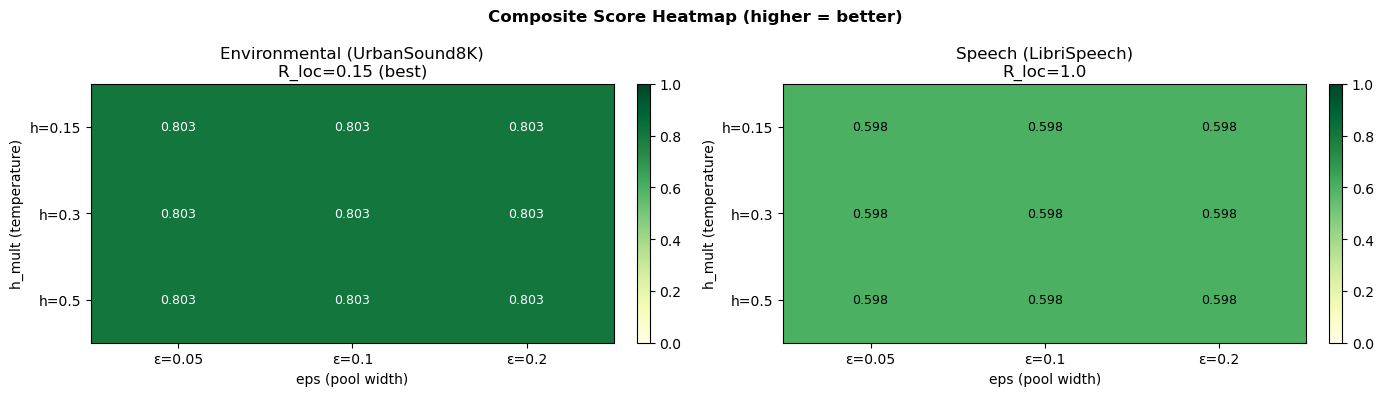

Saved grid_search_heatmap.png

Re-running best environmental config at full output length for detailed report…


100%|██████████| 150/150 [00:00<00:00, 322.14it/s]


Best-config metrics (full length):
  kl_div         : 0.1084
  diversity      : 1.0000
  continuity     : 0.9959
  coverage       : 0.7979
  composite      : 0.9240


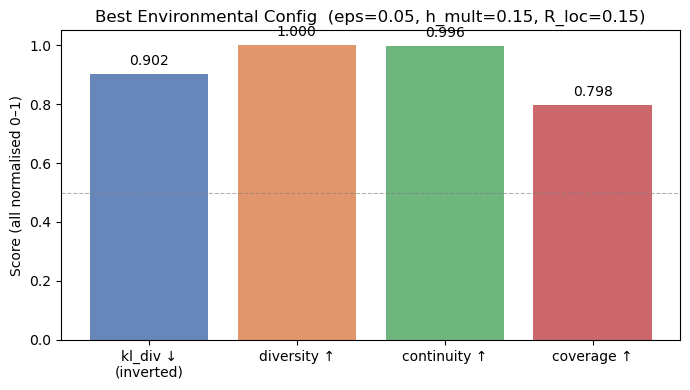

Saved best_config_metrics.png


In [45]:
import itertools

# ── Grid definition ───────────────────────────────────────────────────────────
GRID_EPS    = [0.05, 0.10, 0.20]          # adaptive pool width (both SSD & SSL)
GRID_H_MULT = [0.15, 0.30, 0.50]          # softmax temperature for weighted sampling
GRID_R_LOC_ENV    = [0.15, 0.30]          # locality radius — environmental only
GRID_OUT_STEPS    = 100                    # shorter output for faster grid search
GRID_SEED         = 0                      # fix random seed for reproducibility

set_seed(GRID_SEED)

# ─────────────────────────────────────────────────────────────────────────────
# Part A: Environmental (UrbanSound8K) grid search
# Requires `patches`, `smt_basis`, `raw_audio`, `HOP_LENGTH`, `WINDOW_T`
# from the last file processed in the synthesis loop above.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("GRID SEARCH — Environmental (UrbanSound8K)")
print("Reusing SMT basis from last synthesis run.")
print("=" * 60)

env_results = []
env_grid = list(itertools.product(GRID_EPS, GRID_H_MULT, GRID_R_LOC_ENV))
print(f"Running {len(env_grid)} configurations × {GRID_OUT_STEPS} output frames each…\n")

for eps_v, h_v, rloc_v in tqdm(env_grid, desc="Env grid"):
    set_seed(GRID_SEED)
    out_m, hist = synthesize_audio_mfcc(
        patches=patches,
        smt_basis=smt_basis,
        out_time_steps=GRID_OUT_STEPS,
        R_loc=rloc_v,
        eps=eps_v,
        seed_fg_min=0,
        weighted=True,
        h_mult=h_v,
    )
    metrics = evaluate_synthesis_run(out_m, hist, patches)
    env_results.append({
        "eps": eps_v, "h_mult": h_v, "R_loc": rloc_v, **metrics
    })

env_df = pd.DataFrame(env_results).sort_values("composite", ascending=False).reset_index(drop=True)
print("\nEnvironmental grid search results (sorted by composite score ↓):")
display(env_df.to_html(index=True, float_format="{:.4f}".format))

# Best config
best_env = env_df.iloc[0]
print(f"\nBest environmental config:  eps={best_env['eps']}  "
      f"h_mult={best_env['h_mult']}  R_loc={best_env['R_loc']}  "
      f"→ composite={best_env['composite']:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# Part B: Speech (LibriSpeech) grid search
# R_loc is fixed at 1.0 (locality disabled for cross-utterance speech corpus).
# Requires `speech_patches_tensor` and `smt_basis_speech` from the speech cell.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("GRID SEARCH — Speech (LibriSpeech)")
print("Reusing SMT basis from speech synthesis run.")
print("=" * 60)

speech_grid = list(itertools.product(GRID_EPS, GRID_H_MULT))
print(f"Running {len(speech_grid)} configurations (R_loc fixed at 1.0)…\n")

speech_results = []
for eps_v, h_v in tqdm(speech_grid, desc="Speech grid"):
    set_seed(GRID_SEED)
    out_m, hist = synthesize_audio_mfcc(
        patches=speech_patches_tensor,
        smt_basis=smt_basis_speech,
        out_time_steps=GRID_OUT_STEPS,
        R_loc=1.0,
        eps=eps_v,
        seed_fg_min=0,
        weighted=True,
        h_mult=h_v,
    )
    metrics = evaluate_synthesis_run(out_m, hist, speech_patches_tensor)
    speech_results.append({"eps": eps_v, "h_mult": h_v, "R_loc": 1.0, **metrics})

speech_df = pd.DataFrame(speech_results).sort_values("composite", ascending=False).reset_index(drop=True)
print("\nSpeech grid search results (sorted by composite score ↓):")
display(speech_df.to_html(index=True, float_format="{:.4f}".format))

best_sp = speech_df.iloc[0]
print(f"\nBest speech config:  eps={best_sp['eps']}  h_mult={best_sp['h_mult']}  "
      f"→ composite={best_sp['composite']:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# Visualise: composite score heatmap for each domain
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, title, r_loc_vals in [
    (axes[0], env_df,    "Environmental (UrbanSound8K)",  GRID_R_LOC_ENV),
    (axes[1], speech_df, "Speech (LibriSpeech)",          [1.0]),
]:
    # For env show separate heatmap per R_loc; for speech R_loc=1.0 only
    sub = df[df["R_loc"] == r_loc_vals[0]].copy()
    pivot = sub.pivot(index="h_mult", columns="eps", values="composite")
    im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto",
                   vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"ε={v}" for v in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"h={v}" for v in pivot.index])
    ax.set_xlabel("eps (pool width)")
    ax.set_ylabel("h_mult (temperature)")
    ax.set_title(
        f"{title}\n"
        + (f"R_loc={r_loc_vals[0]}" if len(r_loc_vals) == 1
           else f"R_loc={r_loc_vals[0]} (best)")
    )
    for (ri, ci), val in np.ndenumerate(pivot.values):
        ax.text(ci, ri, f"{val:.3f}", ha="center", va="center",
                fontsize=9, color="black" if val < 0.7 else "white")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Composite Score Heatmap (higher = better)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grid_search_heatmap.png", dpi=150)
plt.show()
print("Saved grid_search_heatmap.png")


# ─────────────────────────────────────────────────────────────────────────────
# Re-run best config at full length and report per-metric bar chart
# ─────────────────────────────────────────────────────────────────────────────
print("\nRe-running best environmental config at full output length for detailed report…")
set_seed(GRID_SEED)
out_best, hist_best = synthesize_audio_mfcc(
    patches=patches,
    smt_basis=smt_basis,
    out_time_steps=OUT_TIME_STEPS,
    R_loc=float(best_env["R_loc"]),
    eps=float(best_env["eps"]),
    seed_fg_min=0,
    weighted=True,
    h_mult=float(best_env["h_mult"]),
)
best_metrics = evaluate_synthesis_run(out_best, hist_best, patches)
print("Best-config metrics (full length):")
for k, v in best_metrics.items():
    print(f"  {k:15s}: {v:.4f}")

metric_labels = ["kl_div ↓\n(inverted)", "diversity ↑", "continuity ↑", "coverage ↑"]
metric_vals   = [
    1 / (1 + best_metrics["kl_div"]),
    best_metrics["diversity"],
    best_metrics["continuity"],
    best_metrics["coverage"],
]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metric_labels, metric_vals, color=["#4c72b0","#dd8452","#55a868","#c44e52"], alpha=0.85)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
for bar, v in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f"{v:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_title(f"Best Environmental Config  "
             f"(eps={best_env['eps']}, h_mult={best_env['h_mult']}, R_loc={best_env['R_loc']})")
ax.set_ylabel("Score (all normalised 0–1)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_config_metrics.png", dpi=150)
plt.show()
print("Saved best_config_metrics.png")

## Phoneme Cluster Analysis: Euclidean MFCC Space vs SMT Space

**Goal.** Do the Sparse Manifold Transform embeddings actually *separate* well-known sound categories better than raw or ZCA-whitened MFCC vectors?

**Method.**
1. Load 30 LibriSpeech dev-clean utterances.
2. Run MMS_FA character-level forced alignment to obtain per-segment timestamps.  
   Map each character to one of six broad classes: *vowel / stop / fricative / nasal / liquid / glide*.
3. Represent each segment as its **mean MFCC vector** (one vector per phoneme occurrence).
4. Fit a speech-specific SMT basis (ZCA → K-means → GEVD) on patches from the same utterances.
5. Project all segment vectors into **three spaces**: raw MFCC, ZCA-whitened, SMT sparse codes.
6. Measure **cluster quality** in each space: Silhouette score ↑, Davies-Bouldin index ↓, inter/intra-centroid distance ratio ↑.
7. Visualise with 2-D PCA scatter plots.

Loading MMS_FA forced-alignment model ...
  sr=16000 Hz  |  vocab=28  |  blank='-'(idx 0)
  Sample labels: ['-', 'a', 'i', 'e', 'n', 'o', 'u', 't', 's', 'r']

Aligning 30 LibriSpeech utterances ...


Aligning:  25%|██▌       | 30/120 [00:22<01:06,  1.35it/s]



  2419 tokens from 30 utterances (0 skipped)
  Class distribution: {'vowel': 924, 'stop': 474, 'fricative': 322, 'nasal': 216, 'liquid': 260, 'glide': 223}

Fitting ZCA + K-means + GEVD + FISTA ...


100%|██████████| 2418/2418 [00:00<00:00, 6130.34it/s]


  X_mfcc (2419, 20)  |  X_zca (2419, 20)  |  X_smt (2419, 16)

Running 5-fold kNN classification (k=5) over all dimensions ...
  kNN accuracy — MFCC: 0.590±0.020 | ZCA: 0.585±0.023 | SMT: 0.502±0.025

Coarticulation metrics (lower ratio → smoother trajectory; higher bigram cos → more consistent direction):
  Space             Consec/Random dist    Bigram cos sim
-------------------------------------------------------
  MFCC                          0.8359            0.2772
  ZCA                           0.8469            0.0872
  SMT                           0.8016            0.0718

Metric                          MFCC (raw)           ZCA           SMT
----------------------------------------------------------------------
  Silhouette ↑                     -0.0298       -0.0067       -0.0274
  Davies-Bouldin ↓                  3.1033        7.0080        7.0882
  Inter/Intra ratio ↑               1.0374        0.4432        0.4662
  kNN accuracy ↑                    0.5899        0.

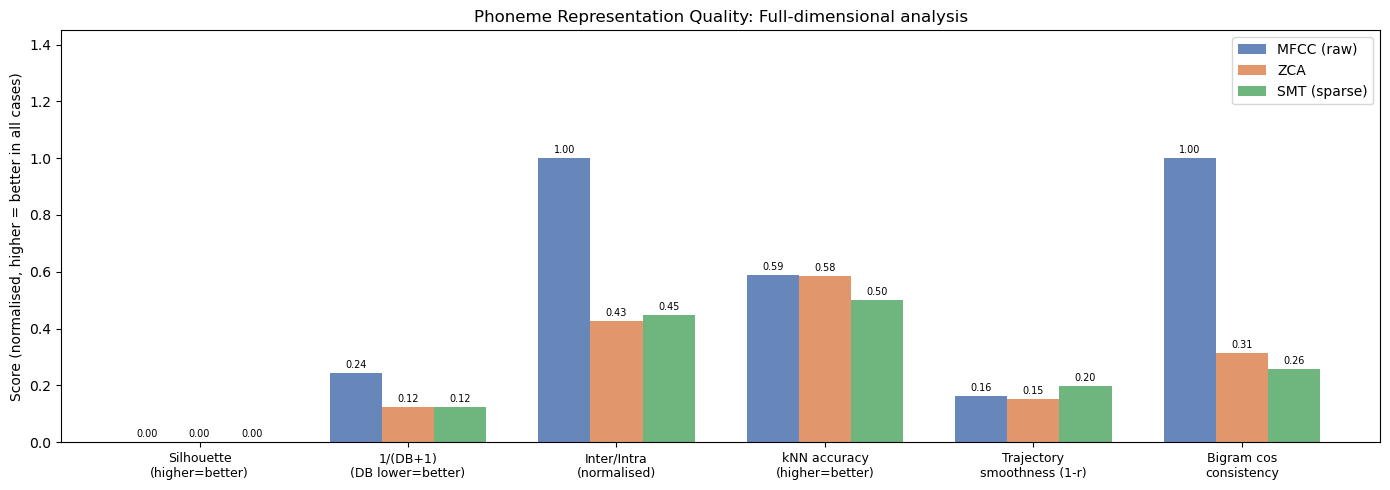

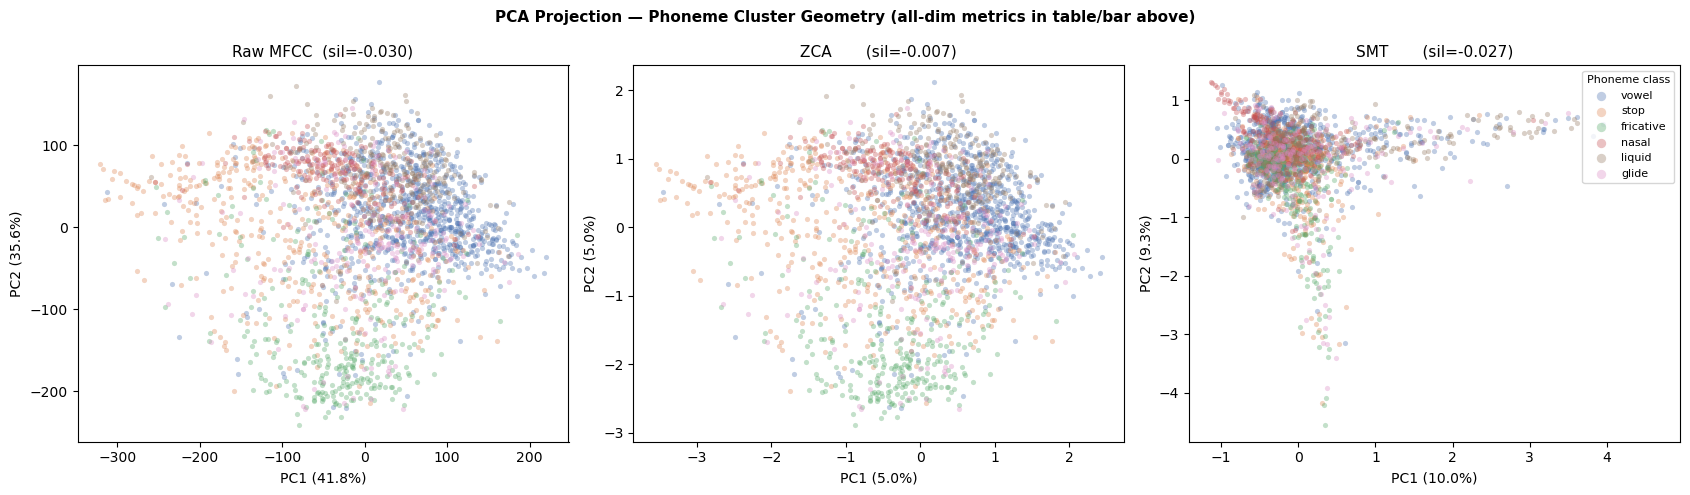

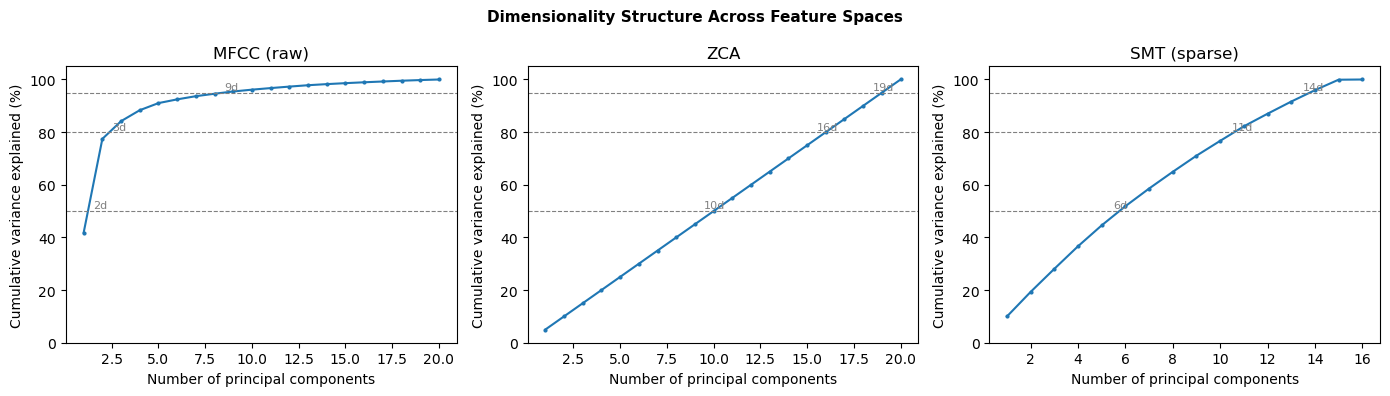

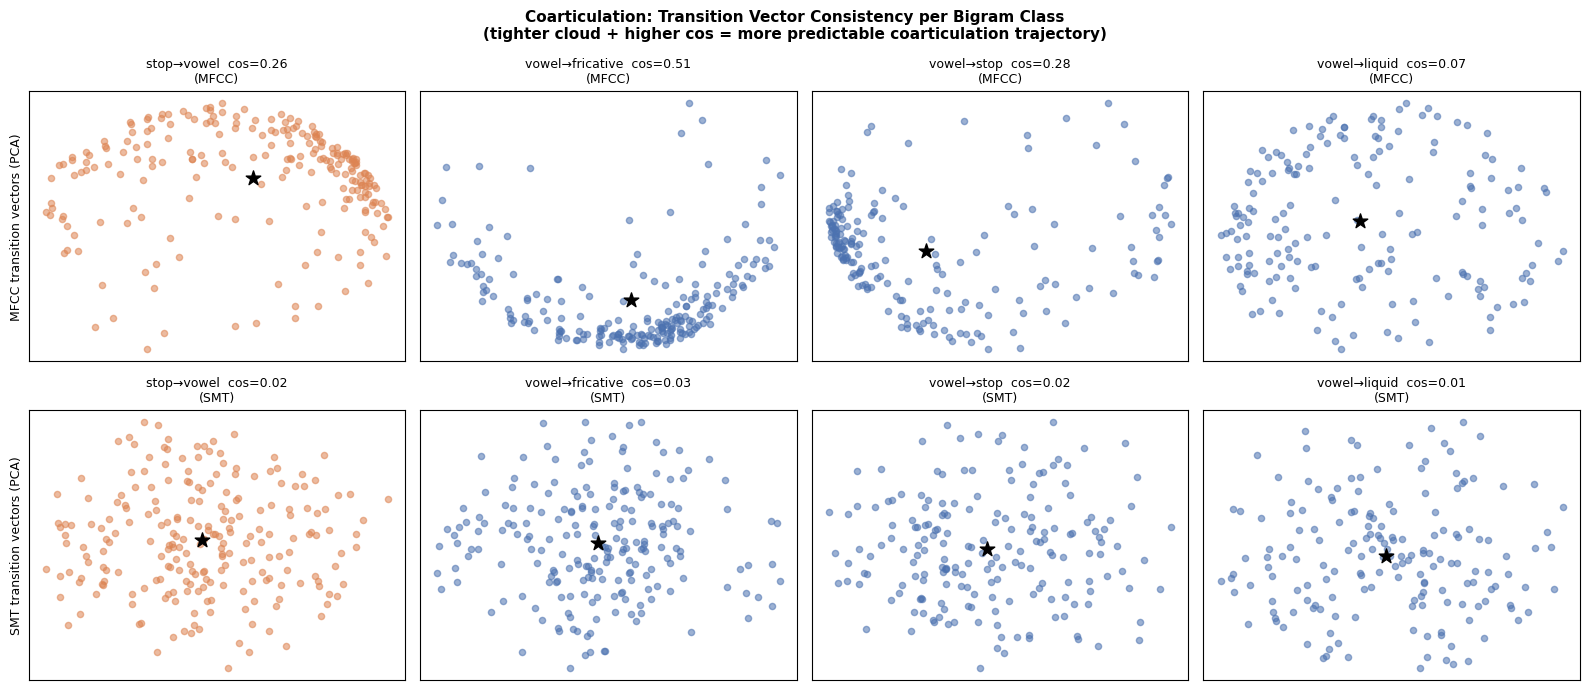


Full-dimensional per-class centroid spread:
  Class            Space    Within-σ    To-others    Sep. ratio
  vowel             MFCC    107.9668     152.2195         1.410
  vowel              ZCA      4.5114       4.4045         0.976
  vowel              SMT      1.9507       1.9343         0.992
  stop              MFCC    131.7690     154.1777         1.170
  stop               ZCA      4.0319       4.5876         1.138
  stop               SMT      1.6730       2.0212         1.208
  fricative         MFCC    113.6606     190.3593         1.675
  fricative          ZCA      3.9184       4.8104         1.228
  fricative          SMT      1.8037       2.0843         1.156
  nasal             MFCC     79.5178     154.6093         1.944
  nasal              ZCA      4.0795       4.7759         1.171
  nasal              SMT      1.7606       2.1643         1.229
  liquid            MFCC     99.2863     152.5429         1.536
  liquid             ZCA      4.3434       4.6281         1

In [46]:
import torchaudio
from torchaudio.pipelines import MMS_FA as _MMS_FA_BUNDLE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings

# ── Constants ─────────────────────────────────────────────────────────────────
PHON_N_UTT      = 30          # LibriSpeech utterances to analyse
PHON_N_MFCC     = 20          # MFCC feature dimensionality
PHON_HOP_MS     = 10.0        # frame hop  (ms)
PHON_WIN_MS     = 25.0        # frame window (ms)
PHON_N_CLUSTERS = 64          # K-means clusters for SMT basis
PHON_SMT_DIM    = 16          # SMT embedding dimensionality

# Broad phoneme classes matching MMS_FA's lowercase vocab
_CHAR_CLASS = {
    "a": "vowel",     "e": "vowel",     "i": "vowel",
    "o": "vowel",     "u": "vowel",
    "b": "stop",      "d": "stop",      "g": "stop",
    "k": "stop",      "p": "stop",      "t": "stop",
    "q": "stop",
    "f": "fricative", "s": "fricative", "v": "fricative",
    "x": "fricative", "z": "fricative", "c": "fricative",
    "m": "nasal",     "n": "nasal",
    "l": "liquid",    "r": "liquid",
    "h": "glide",     "j": "glide",     "w": "glide",     "y": "glide",
}
_CLASS_NAMES  = ["vowel", "stop", "fricative", "nasal", "liquid", "glide"]
_CLASS_COLORS = {
    "vowel":     "#4c72b0",
    "stop":      "#dd8452",
    "fricative": "#55a868",
    "nasal":     "#c44e52",
    "liquid":    "#937860",
    "glide":     "#da8bc3",
}

# ── 1.  Load MMS_FA forced-alignment model ────────────────────────────────────
print("Loading MMS_FA forced-alignment model ...")
_fa_model  = _MMS_FA_BUNDLE.get_model(with_star=False)
_fa_labels = _MMS_FA_BUNDLE.get_labels(star=None)
_fa_sr     = _MMS_FA_BUNDLE.sample_rate
_fa_dict   = {ch: i for i, ch in enumerate(_fa_labels)}
_fa_blank  = _fa_dict.get("-", 0)   # MMS_FA blank token index
print(f"  sr={_fa_sr} Hz  |  vocab={len(_fa_labels)}  |  blank='{_fa_labels[_fa_blank]}'(idx {_fa_blank})")
print(f"  Sample labels: {list(_fa_labels[:10])}")


def _align_and_extract(audio_np: np.ndarray, sample_rate: int,
                       transcript: str, n_mfcc: int = PHON_N_MFCC,
                       hop_ms: float = PHON_HOP_MS, win_ms: float = PHON_WIN_MS):
    """
    Forced-align one utterance and return per-phoneme MFCC vectors.
    Returns list of (char, broad_class, mean_mfcc_vec) in temporal order.
    Uses torchaudio.functional.forced_align / merge_tokens (v2.x API).
    """
    if not isinstance(audio_np, np.ndarray) or audio_np.ndim != 1:
        return []
    if sample_rate != _fa_sr:
        audio_np = librosa.resample(audio_np, orig_sr=sample_rate, target_sr=_fa_sr)
    audio_np = audio_np.astype(np.float32)

    hop = int(round(_fa_sr * hop_ms / 1000))
    win = int(round(_fa_sr * win_ms / 1000))
    mfcc_full = librosa.feature.mfcc(y=audio_np, sr=_fa_sr, n_mfcc=n_mfcc,
                                      hop_length=hop, win_length=win)
    n_frames = mfcc_full.shape[1]

    token_ids = [_fa_dict[c] for c in transcript.lower() if c in _fa_dict]
    if len(token_ids) < 2:
        return []

    waveform = torch.from_numpy(audio_np).float().unsqueeze(0)
    with torch.no_grad():
        emissions, _ = _fa_model(waveform)
    emissions = torch.log_softmax(emissions, dim=-1)
    targets   = torch.tensor([token_ids], dtype=torch.int32)

    try:
        ali_t, ali_s = torchaudio.functional.forced_align(
            emissions, targets, blank=_fa_blank)
        segments = torchaudio.functional.merge_tokens(
            ali_t[0], ali_s[0], blank=_fa_blank)
    except Exception:
        return []

    results = []
    ratio = n_frames / max(emissions.shape[1], 1)
    for seg in segments:
        ch  = _fa_labels[seg.token]
        cls = _CHAR_CLASS.get(ch)
        if cls is None:
            continue
        s = min(int(seg.start * ratio), n_frames - 1)
        e = min(max(s + 1, int(seg.end * ratio)),  n_frames)
        vec = mfcc_full[:, s:e].mean(axis=1)
        results.append((ch, cls, vec))
    return results


# ── 2.  Collect phoneme vectors from LibriSpeech (reuses working loader) ─────
print(f"\nAligning {PHON_N_UTT} LibriSpeech utterances ...")
phon_vecs_list = []   # MFCC vector per token
phon_cls_list  = []   # broad phoneme class per token
phon_char_list = []   # character per token
phon_utt_list  = []   # utterance index (for trajectory analysis)
phon_pos_list  = []   # position within utterance (for trajectory analysis)
n_loaded = 0;  n_errors = 0

for idx in tqdm(range(min(PHON_N_UTT * 4, len(librispeech_ds))),
                desc="Aligning", leave=True):
    if n_loaded >= PHON_N_UTT:
        break
    try:
        audio_raw, _ = load_librispeech_item(librispeech_ds, idx)
        transcript   = str(librispeech_ds.get_metadata(idx)[2])
        records      = _align_and_extract(audio_raw, TARGET_SR, transcript)
        if not records:
            continue
        for pos, (ch, cls, vec) in enumerate(records):
            phon_vecs_list.append(vec)
            phon_cls_list.append(cls)
            phon_char_list.append(ch)
            phon_utt_list.append(n_loaded)
            phon_pos_list.append(pos)
        n_loaded += 1
    except Exception as exc:
        n_errors += 1
        if n_errors <= 3:
            print(f"  [warn] idx={idx}: {type(exc).__name__}: {exc}")

if not phon_vecs_list:
    raise RuntimeError(f"No phoneme vectors after {PHON_N_UTT*4} attempts ({n_errors} errors).")

X_mfcc = np.stack(phon_vecs_list, axis=0).astype(np.float32)  # (N, n_mfcc)
y_cls  = np.array(phon_cls_list)
utt_arr = np.array(phon_utt_list)
pos_arr = np.array(phon_pos_list)
cls_counts = {c: int((y_cls == c).sum()) for c in _CLASS_NAMES if (y_cls == c).any()}
print(f"\n  {len(X_mfcc)} tokens from {n_loaded} utterances ({n_errors} skipped)")
print(f"  Class distribution: {cls_counts}")

# ── 3.  Fit ZCA → K-means → GEVD → SMT basis ─────────────────────────────────
print("\nFitting ZCA + K-means + GEVD + FISTA ...")
zca_m   = zca_whitening_matrix(X_mfcc.T)
X_zca   = (zca_m @ X_mfcc.T).T
X_znorm = normalize(X_zca, norm="l2")

km = MiniBatchKMeans(n_clusters=PHON_N_CLUSTERS, random_state=42, n_init=10)
km.fit(X_znorm);  labels_km = km.labels_

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ev_p, evec_p = spectral_decomp(labels_km, [(0, len(labels_km))], PHON_N_CLUSTERS)

d_smt        = min(PHON_SMT_DIM, evec_p.shape[1])
basis_p      = torch.from_numpy(evec_p[:, :d_smt].astype(np.float32))  # (K, d)
cc_t         = torch.from_numpy(normalize(km.cluster_centers_, norm="l2").T.astype(np.float32))
sparse_codes = compute_smt_embeddings(
    torch.from_numpy(X_znorm.T.astype(np.float32)), cc_t, lambd=0.1, num_iter=50)
X_smt        = (basis_p.T @ sparse_codes).T.numpy()                     # (N, d_smt)

print(f"  X_mfcc {X_mfcc.shape}  |  X_zca {X_zca.shape}  |  X_smt {X_smt.shape}")

# ── 4.  Full-dimensional cluster metrics ──────────────────────────────────────
valid_cls = [c for c in _CLASS_NAMES if (y_cls == c).sum() >= 2]
mask_v    = np.isin(y_cls, valid_cls)
y_int     = np.array([_CLASS_NAMES.index(c) for c in y_cls[mask_v]])

def _cluster_metrics(X):
    Xv  = X[mask_v]
    sil = silhouette_score(Xv, y_int, metric="euclidean")
    db  = davies_bouldin_score(Xv, y_int)
    cls_ids   = np.unique(y_int)
    centroids = np.array([Xv[y_int == c].mean(axis=0) for c in cls_ids])
    intra  = np.mean([np.linalg.norm(Xv[y_int == c] - centroids[i], axis=1).mean()
                      for i, c in enumerate(cls_ids)])
    iis    = [np.linalg.norm(centroids[i]-centroids[j])
              for i in range(len(cls_ids)) for j in range(i+1, len(cls_ids))]
    return {"silhouette": sil,
            "davies_bouldin": db,
            "inter_intra": np.mean(iis) / (intra + 1e-8)}

m_raw = _cluster_metrics(X_mfcc)
m_zca = _cluster_metrics(X_zca)
m_smt = _cluster_metrics(X_smt)

# ── 5.  kNN phoneme classification (5-fold cross-validation) ─────────────────
print("\nRunning 5-fold kNN classification (k=5) over all dimensions ...")
def _knn_acc(X):
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=5, metric="euclidean"),
        X[mask_v], y_int, cv=5, scoring="accuracy")
    return scores.mean(), scores.std()

knn_raw_m, knn_raw_s = _knn_acc(X_mfcc)
knn_zca_m, knn_zca_s = _knn_acc(X_zca)
knn_smt_m, knn_smt_s = _knn_acc(X_smt)

print(f"  kNN accuracy — MFCC: {knn_raw_m:.3f}±{knn_raw_s:.3f} | "
      f"ZCA: {knn_zca_m:.3f}±{knn_zca_s:.3f} | "
      f"SMT: {knn_smt_m:.3f}±{knn_smt_s:.3f}")

# ── 6.  Coarticulation: transition trajectory consistency ─────────────────────
# Consecutive phoneme pairs (same utterance, adjacent positions)
consec_mask = ((utt_arr[:-1] == utt_arr[1:]) & (pos_arr[1:] == pos_arr[:-1] + 1))
consec_idx  = np.where(consec_mask)[0]   # indices i where (i, i+1) is consecutive

rng_c = np.random.default_rng(42)
rand_idx = rng_c.integers(0, len(X_mfcc), size=(len(consec_idx) * 2, 2))
rand_idx = rand_idx[rand_idx[:, 0] != rand_idx[:, 1]][:len(consec_idx)]

def _transition_stats(X):
    """
    Returns:
      ratio  – mean(consecutive dist) / mean(random dist); <1 means consecutive
               phonemes are closer than chance (smoother trajectory)
      bigram_consistency – mean pairwise cosine similarity of transition
               vectors for the same bigram class; higher = more directionally
               consistent = better coarticulation model
    """
    consec_d = np.linalg.norm(X[consec_idx] - X[consec_idx + 1], axis=1)
    rand_d   = np.linalg.norm(X[rand_idx[:, 0]] - X[rand_idx[:, 1]], axis=1)
    ratio    = consec_d.mean() / (rand_d.mean() + 1e-8)

    # Transition vectors: vec_{t+1} - vec_t for each consecutive pair
    tvecs = X[consec_idx + 1] - X[consec_idx]          # (C, dim)
    norms = np.linalg.norm(tvecs, axis=1, keepdims=True)
    tvecs_n = tvecs / (norms + 1e-8)                    # unit transition vectors

    # Bigram consistency: group by (class_from, class_to)
    bigram_cos = {}
    for pi, i in enumerate(consec_idx):
        key = (y_cls[i], y_cls[i + 1])
        if key not in bigram_cos:
            bigram_cos[key] = []
        bigram_cos[key].append(tvecs_n[pi])

    cos_scores = []
    for key, vecs in bigram_cos.items():
        if len(vecs) < 3:
            continue
        V = np.stack(vecs)
        G = V @ V.T                          # pairwise cosine similarities
        n = len(V)
        cos_scores.append(G[np.triu_indices(n, k=1)].mean())

    bigram_cons = float(np.mean(cos_scores)) if cos_scores else 0.0
    return ratio, bigram_cons, tvecs, bigram_cos

t_raw_ratio, t_raw_bc, tvecs_raw, bg_raw = _transition_stats(X_mfcc)
t_zca_ratio, t_zca_bc, tvecs_zca, bg_zca = _transition_stats(X_zca)
t_smt_ratio, t_smt_bc, tvecs_smt, bg_smt = _transition_stats(X_smt)

print(f"\nCoarticulation metrics (lower ratio → smoother trajectory; "
      f"higher bigram cos → more consistent direction):")
print(f"  {'Space':<14}  {'Consec/Random dist':>20}  {'Bigram cos sim':>16}")
print("-"*55)
for label, r, bc in [("MFCC", t_raw_ratio, t_raw_bc),
                      ("ZCA",  t_zca_ratio, t_zca_bc),
                      ("SMT",  t_smt_ratio, t_smt_bc)]:
    print(f"  {label:<14}  {r:>20.4f}  {bc:>16.4f}")

# ── 7.  Full metric table ─────────────────────────────────────────────────────
print(f"\n{'Metric':<28}  {'MFCC (raw)':>12}  {'ZCA':>12}  {'SMT':>12}")
print("-"*70)
rows = [
    ("Silhouette ↑",          m_raw["silhouette"],    m_zca["silhouette"],    m_smt["silhouette"]),
    ("Davies-Bouldin ↓",      m_raw["davies_bouldin"],m_zca["davies_bouldin"],m_smt["davies_bouldin"]),
    ("Inter/Intra ratio ↑",   m_raw["inter_intra"],   m_zca["inter_intra"],   m_smt["inter_intra"]),
    ("kNN accuracy ↑",        knn_raw_m,              knn_zca_m,              knn_smt_m),
    ("Consec/Rand dist ↓",    t_raw_ratio,            t_zca_ratio,            t_smt_ratio),
    ("Bigram direction cos ↑",t_raw_bc,               t_zca_bc,               t_smt_bc),
]
for label, rv, zv, sv in rows:
    print(f"  {label:<26}  {rv:>12.4f}  {zv:>12.4f}  {sv:>12.4f}")

# ── 8.  Bar chart — all metrics (normalised so higher=better everywhere) ──────
max_iir = max(m_raw["inter_intra"], m_zca["inter_intra"], m_smt["inter_intra"]) + 1e-8
max_cos = max(t_raw_bc, t_zca_bc, t_smt_bc) + 1e-8

def _normalise(m, knn_m, t_ratio, t_bc):
    return [
        max(0, m["silhouette"]),                     # silhouette (higher=better)
        1.0 / (m["davies_bouldin"] + 1.0),           # DB (lower=better → invert)
        m["inter_intra"] / max_iir,                  # inter/intra (higher=better)
        knn_m,                                       # kNN accuracy (higher=better)
        max(0, 1.0 - t_ratio),                       # consec/rand (lower=better → invert, clip≥0)
        t_bc / (max_cos + 1e-8),                     # bigram cos (higher=better)
    ]

bar_metric_labels = [
    "Silhouette\n(higher=better)",
    "1/(DB+1)\n(DB lower=better)",
    "Inter/Intra\n(normalised)",
    "kNN accuracy\n(higher=better)",
    "Trajectory\nsmoothness (1-r)",
    "Bigram cos\nconsistency",
]
bar_spaces = ["MFCC (raw)", "ZCA", "SMT (sparse)"]
bar_colors = ["#4c72b0", "#dd8452", "#55a868"]
bar_vals   = [_normalise(m_raw, knn_raw_m, t_raw_ratio, t_raw_bc),
              _normalise(m_zca, knn_zca_m, t_zca_ratio, t_zca_bc),
              _normalise(m_smt, knn_smt_m, t_smt_ratio, t_smt_bc)]

x_b = np.arange(len(bar_metric_labels));   w_b = 0.25
fig, ax = plt.subplots(figsize=(14, 5))
for i, (sp, vals, col) in enumerate(zip(bar_spaces, bar_vals, bar_colors)):
    bars = ax.bar(x_b + i * w_b, vals, w_b, label=sp, color=col, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x_b + w_b);  ax.set_xticklabels(bar_metric_labels, fontsize=9)
ax.set_ylabel("Score (normalised, higher = better in all cases)")
ax.set_ylim(0, 1.45);  ax.set_title("Phoneme Representation Quality: Full-dimensional analysis")
ax.legend();  plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phoneme_metrics_all.png", dpi=150);  plt.show()

# ── 9.  PCA scatter (2-D visualisation of cluster geometry) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (X_emb, sil, title) in zip(axes, [
        (X_mfcc, m_raw["silhouette"], f"Raw MFCC  (sil={m_raw['silhouette']:.3f})"),
        (X_zca,  m_zca["silhouette"], f"ZCA       (sil={m_zca['silhouette']:.3f})"),
        (X_smt,  m_smt["silhouette"], f"SMT       (sil={m_smt['silhouette']:.3f})"),
]):
    pca2 = PCA(n_components=2, random_state=42)
    Z  = pca2.fit_transform(X_emb[mask_v])
    vr = pca2.explained_variance_ratio_
    for cls in valid_cls:
        m = y_cls[mask_v] == cls
        ax.scatter(Z[m, 0], Z[m, 1], c=_CLASS_COLORS[cls],
                   label=cls, alpha=0.35, s=14, linewidths=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f"PC1 ({vr[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({vr[1]*100:.1f}%)")
axes[2].legend(loc="upper right", fontsize=8, markerscale=1.8,
               title="Phoneme class", title_fontsize=8)
plt.suptitle("PCA Projection — Phoneme Cluster Geometry (all-dim metrics in table/bar above)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phoneme_pca_scatter.png", dpi=150);  plt.show()

# ── 10.  PCA variance explained curve ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (X_emb, name) in zip(axes, [
        (X_mfcc, "MFCC (raw)"), (X_zca, "ZCA"), (X_smt, "SMT (sparse)")]):
    pca_full = PCA(random_state=42).fit(X_emb[mask_v])
    cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100
    ax.plot(np.arange(1, len(cum_var)+1), cum_var, marker=".", ms=4)
    for thresh in [50, 80, 95]:
        idx_t = np.searchsorted(cum_var, thresh)
        if idx_t < len(cum_var):
            ax.axhline(thresh, color="gray", lw=0.8, ls="--")
            ax.text(idx_t + 0.5, thresh + 1, f"{idx_t+1}d", fontsize=8, color="gray")
    ax.set_xlabel("Number of principal components")
    ax.set_ylabel("Cumulative variance explained (%)")
    ax.set_title(name)
    ax.set_ylim(0, 105)
plt.suptitle("Dimensionality Structure Across Feature Spaces", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phoneme_pca_variance.png", dpi=150);  plt.show()

# ── 11.  Coarticulation: transition vector PCA (MFCC vs SMT) ─────────────────
# For the 4 most common bigrams, visualise transition vectors in 2D PCA
# A tight, directionally-consistent cluster → the space captures coarticulation
def _top_bigrams(bg_dict, n=4):
    return sorted(bg_dict.items(), key=lambda x: -len(x[1]))[:n]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
top_keys = [k for k, _ in _top_bigrams(bg_smt, 4)]   # pick bigrams by SMT count
for col, key in enumerate(top_keys):
    for row, (tvecs_dict, space_name, X_emb) in enumerate([
            (bg_raw, "MFCC", X_mfcc),
            (bg_smt, "SMT",  X_smt)]):
        ax = axes[row][col]
        if key not in tvecs_dict or len(tvecs_dict[key]) < 3:
            ax.set_visible(False);  continue
        V = np.stack(tvecs_dict[key])        # (n_bigrams_of_this_type, dim)
        if V.shape[1] > 2:
            pca_t = PCA(n_components=2, random_state=42).fit_transform(V)
        else:
            pca_t = V
        ax.scatter(pca_t[:, 0], pca_t[:, 1], alpha=0.55, s=20,
                   color=_CLASS_COLORS.get(key[0], "#999"))
        # draw centroid and variance ellipse (std along each axis)
        mu = pca_t.mean(axis=0)
        ax.scatter(*mu, marker="*", s=120, color="black", zorder=5)
        # mean pairwise cos of unit vecs
        nv = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-8)
        cos_m = (nv @ nv.T)[np.triu_indices(len(nv), k=1)].mean()
        ax.set_title(f"{key[0]}→{key[1]}  cos={cos_m:.2f}\n({space_name})", fontsize=9)
        ax.set_xticks([]);  ax.set_yticks([])
axes[0][0].set_ylabel("MFCC transition vectors (PCA)", fontsize=9)
axes[1][0].set_ylabel("SMT transition vectors (PCA)",  fontsize=9)
plt.suptitle("Coarticulation: Transition Vector Consistency per Bigram Class\n"
             "(tighter cloud + higher cos = more predictable coarticulation trajectory)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phoneme_coarticulation.png", dpi=150);  plt.show()

# ── 12.  Per-class centroid distance table (full-dimensional) ─────────────────
print("\nFull-dimensional per-class centroid spread:")
print(f"  {'Class':<12}  {'Space':>8}  {'Within-σ':>10}  {'To-others':>11}  {'Sep. ratio':>12}")
for cls in valid_cls:
    m_cls = y_cls[mask_v] == cls
    for lbl, Xv in [("MFCC", X_mfcc[mask_v]), ("ZCA", X_zca[mask_v]), ("SMT", X_smt[mask_v])]:
        pts = Xv[m_cls]; oth = Xv[~m_cls]
        c   = pts.mean(axis=0)
        ws  = np.linalg.norm(pts - c, axis=1).mean()
        od  = np.linalg.norm(oth - c, axis=1).mean()
        print(f"  {cls:<12}  {lbl:>8}  {ws:>10.4f}  {od:>11.4f}  {od/(ws+1e-8):>12.3f}")

print(f"\nSaved: phoneme_metrics_all.png, phoneme_pca_scatter.png, "
      f"phoneme_pca_variance.png, phoneme_coarticulation.png")


# Project Coverage Summary

| Proposal Goal | Notebook | Status |
|---|---|---|
| Non-parametric sampling — Efros & Leung style | `Final.ipynb` (synthesis loop, Pillar 1 SSD) | ✅ |
| SMT high-level statistic for candidate selection | `Final.ipynb` (Pillar 3, adaptive R_SSL) | ✅ |
| Temporal locality / co-occurrence | `Final.ipynb` (Pillar 2, R_loc) | ✅ |
| UrbanSound8K audio textures | `Final.ipynb` (dataset load → synthesize) | ✅ |
| Inversion — resample from source audio | `Final.ipynb` → `reconstruct_audio("stitch")` | ✅ |
| Inversion — neural vocoder | `Final.ipynb` cell 17 (WaveRNN) | ✅ |
| LibriSpeech patches with forced alignment | `Representation.ipynb` §3 | ✅ |
| kNN phoneme classification (MFCC vs ZCA vs SMT) | `Representation.ipynb` §5 | ✅ |
| Cluster geometry: Euclidean vs SMT | `Representation.ipynb` §6 | ✅ |
| Coarticulation trajectory consistency | `Representation.ipynb` §7 | ✅ |
| Temporal co-occurrence analysis | `Representation.ipynb` §8 | ✅ |

## Three-Pillar Non-Parametric Sampler (Lu et al. arXiv 2510.22196 §2.4)
- **Pillar 1 (SSD):** `R_SSD(p) = (1+ε) · min d_SSD` — **adaptive** per synthesis step ✓
- **Pillar 2 (Locality):** `R_loc` — **fixed** hyperparameter ✓
- **Pillar 3 (SMT/SSL):** `R_SSL(p) = (1+ε) · min d_SSL` — **adaptive** per synthesis step ✓

# Task 1 — Clustering Analysis & SMT Semantic Mapping

**Goal:** Run K-means (K=100) on UrbanSound8K spectrogram patches and visualise
cluster membership (colour) vs ground-truth class label (marker shape) in a 2-D
projection.  Then repeat after projecting each patch through the SMT basis with FISTA
(k-sparse codes) and compare whether the SMT space shows more coherent class structure.

In [47]:
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# ── UrbanSound8K class map ────────────────────────────────────────────────────
US8K_CLASSES = {
    0: "air_conditioner", 1: "car_horn",       2: "children_playing",
    3: "dog_bark",        4: "drilling",        5: "engine_idling",
    6: "gun_shot",        7: "jackhammer",      8: "siren",
    9: "street_music",
}
# Markers cycle for up to 10 classes
CLASS_MARKERS = ["o", "s", "^", "D", "v", "P", "*", "X", "h", "+"]

def parse_urbansound_class(path: Path) -> int | None:
    """Extract classID from UrbanSound8K filename: {slice}-{fsid}-{classID}-{take}.ext"""
    try:
        parts = path.stem.split("-")
        return int(parts[2])
    except (IndexError, ValueError):
        return None

# ── Configuration ─────────────────────────────────────────────────────────────
T1_N_FILES_PER_CLASS  = 20     # audio files per class to sample from
T1_MAX_PATCHES_FILE   = 60     # patches to keep per file (random crop)
T1_N_MFCC             = 40
T1_SR                 = 22050
T1_DURATION           = 4.0
T1_WINDOW_W           = 11     # MFCC time frames per patch

# ── Extract patches with class labels ────────────────────────────────────────
print("Parsing class labels from audio filenames …")
labelled_files: dict[int, list[Path]] = {c: [] for c in US8K_CLASSES}
for f in audio_files:
    cid = parse_urbansound_class(f)
    if cid is not None and cid in labelled_files:
        labelled_files[cid].append(f)

# Report coverage
for cid, files in labelled_files.items():
    print(f"  class {cid:2d}  {US8K_CLASSES[cid]:<22s}: {len(files)} files")

# ── Build patch matrix with metadata ─────────────────────────────────────────
rng_t1    = np.random.default_rng(42)

t1_patches_list: list[np.ndarray] = []
t1_labels_list:  list[int]        = []

for cid, files in tqdm(labelled_files.items(), desc="Classes"):
    sample_files = list(rng_t1.choice(files, size=min(T1_N_FILES_PER_CLASS, len(files)), replace=False))
    for fpath in sample_files:
        try:
            y, _ = librosa.load(str(fpath), sr=T1_SR, duration=T1_DURATION)
        except Exception:
            continue
        target_len = int(T1_SR * T1_DURATION)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]

        mfcc = librosa.feature.mfcc(y=y, sr=T1_SR, n_mfcc=T1_N_MFCC)  # (F, T)
        mfcc = (mfcc - mfcc.mean()) / (mfcc.std() + 1e-6)

        n_frames  = mfcc.shape[1]
        n_patches = max(0, n_frames - T1_WINDOW_W + 1)
        if n_patches < 1:
            continue

        starts = np.arange(n_patches)
        if len(starts) > T1_MAX_PATCHES_FILE:
            starts = rng_t1.choice(starts, size=T1_MAX_PATCHES_FILE, replace=False)

        for s in starts:
            p = mfcc[:, s : s + T1_WINDOW_W].flatten()  # (F * W,)
            t1_patches_list.append(p)
            t1_labels_list.append(cid)

t1_patches = np.stack(t1_patches_list, axis=0).astype(np.float32)  # (N, F*W)
t1_labels  = np.array(t1_labels_list, dtype=np.int32)              # (N,)
print(f"\nTotal patches: {t1_patches.shape[0]:,}  | feature dim: {t1_patches.shape[1]}")
print("Per-class counts:", {US8K_CLASSES[c]: int((t1_labels == c).sum()) for c in US8K_CLASSES})


Parsing class labels from audio filenames …
  class  0  air_conditioner       : 6132 files
  class  1  car_horn              : 881 files
  class  2  children_playing      : 443 files
  class  3  dog_bark              : 300 files
  class  4  drilling              : 239 files
  class  5  engine_idling         : 110 files
  class  6  gun_shot              : 85 files
  class  7  jackhammer            : 97 files
  class  8  siren                 : 58 files
  class  9  street_music          : 81 files


Classes:   0%|          | 0/10 [00:00<?, ?it/s]


Total patches: 12,000  | feature dim: 440
Per-class counts: {'air_conditioner': 1200, 'car_horn': 1200, 'children_playing': 1200, 'dog_bark': 1200, 'drilling': 1200, 'engine_idling': 1200, 'gun_shot': 1200, 'jackhammer': 1200, 'siren': 1200, 'street_music': 1200}


## 1-A  K-means on Raw Spectrogram Patches (K = 100)

Fitting K-means (K=100) on raw MFCC patches …
PCA → t-SNE (this can take ~1 minute) …
Silhouette (cluster labels): 0.2233
Silhouette (class labels):   -0.0801


/tmp/ipykernel_299864/3706340300.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = cm.get_cmap("tab20b", T1_K)
/tmp/ipykernel_299864/3706340300.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  class_cmap = cm.get_cmap("tab10", len(US8K_CLASSES))


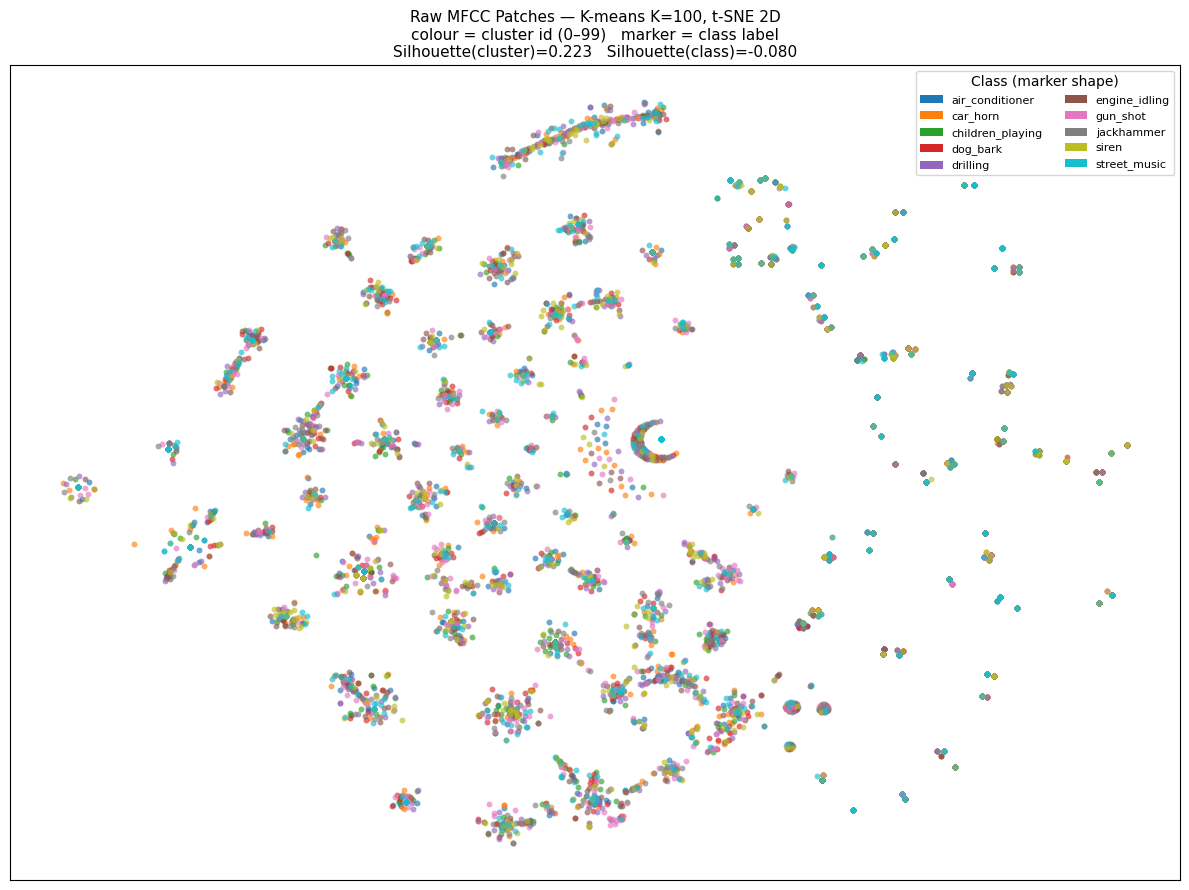

Saved t1_raw_kmeans_tsne.png


In [ ]:
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from sklearn.metrics import silhouette_score

# ── L2-normalise raw patches ────────────────────────────you have raw mfcc patches labelled as two diferrent things, can you double check?1──────────────────────
t1_patches_norm = normalize(t1_patches, norm="l2")

# ── K-means K=100 on raw patches ─────────────────────────────────────────────
T1_K = 100
print(f"Fitting K-means (K={T1_K}) on raw MFCC patches …")
km_raw = MiniBatchKMeans(n_clusters=T1_K, random_state=42, n_init=10, batch_size=4096)
km_raw.fit(t1_patches_norm)
km_raw_labels = km_raw.labels_       # cluster assignment per patch

# ── 2-D projection: PCA → t-SNE ───────────────────────────────────────────────
# First reduce to 50-D with PCA for speed, then t-SNE to 2-D
print("PCA → t-SNE (this can take ~1 minute) …")
N_VIZ = min(6000, len(t1_patches_norm))
viz_idx = rng_t1.choice(len(t1_patches_norm), size=N_VIZ, replace=False)

pca50 = PCA(n_components=50, random_state=42)
X_pca50 = pca50.fit_transform(t1_patches_norm[viz_idx])
# sklearn TSNE uses `max_iter` rather than `n_iter` in recent releases
# remove learning_rate="auto" for compatibility if necessary
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000, init="pca")
X_2d_raw = tsne.fit_transform(X_pca50)

viz_km_labels  = km_raw_labels[viz_idx]
viz_cls_labels = t1_labels[viz_idx]

# ── Silhouette score (cluster quality, class quality) ─────────────────────────
sil_cluster_raw = silhouette_score(t1_patches_norm[viz_idx], viz_km_labels,  sample_size=2000, random_state=42)
sil_class_raw   = silhouette_score(t1_patches_norm[viz_idx], viz_cls_labels, sample_size=2000, random_state=42)
print(f"Silhouette (cluster labels): {sil_cluster_raw:.4f}")
print(f"Silhouette (class labels):   {sil_class_raw:.4f}")

# ── Cluster colours (one per K, using a continuous colormap) ─────────────────
cluster_cmap = cm.get_cmap("tab20b", T1_K)
cluster_colors = cluster_cmap(viz_km_labels / T1_K)

# ── Class color map (one colour per class) ────────────────────────────────────
class_cmap = cm.get_cmap("tab10", len(US8K_CLASSES))
class_color_map = {cid: class_cmap(i) for i, cid in enumerate(US8K_CLASSES.keys())}


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
for ci, (cid, name) in enumerate(US8K_CLASSES.items()):
    mask = viz_cls_labels == cid
    if not mask.any():
        continue
    ax.scatter(
        X2d[mask, 0], X2d[mask, 1],
        c=[class_color_map[cid]],
        s=18, alpha=0.65, linewidths=0, label=name)
# Legend: one entry per class (marker) only — colour encodes cluster
legend_handles = [
    mpatches.Patch(facecolor=class_color_map[cid], label=name)
    for cid, name in enumerate(US8K_CLASSES.values())
]

ax.legend(handles=legend_handles, title="Class (marker shape)",
          loc="upper right", fontsize=8, ncol=2)
ax.set_title(f"Raw MFCC Patches — K-means K={T1_K}, t-SNE 2D\n"
    f"colour = cluster id (0–{T1_K-1})   marker = class label\n"
    f"Silhouette(cluster)={sil_cluster_raw:.3f}   Silhouette(class)={sil_class_raw:.3f}",
    fontsize=11,
)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "t1_raw_kmeans_tsne.png", dpi=150)
plt.show()

print("Saved t1_raw_kmeans_tsne.png")

## 1-B  K-means on SMT-Embedded Patches (K = 100)

Learn a compact SMT basis from the same Task-1 patches, encode each patch as its
FISTA sparse code, run K-means on the code vectors, and compare the t-SNE layout
to the raw-patch version above.  Tighter per-class clusters ⟹ SMT captures more
semantically meaningful structure.

ZCA-whitening Task-1 patches …
K-means K=200 on whitened patches for SMT dictionary …
  200 utterance bounds  |  covering 12000/12000 patches
Spectral decomposition (slowness matrix) …


Building M:   0%|          | 0/200 [00:00<?, ?it/s]

Task-1 SMT basis: torch.Size([440, 64])
FISTA-encoding all patches (lambda=0.1) …


Encoding:   0%|          | 0/12 [00:00<?, ?it/s]

Sparse codes: (12000, 64)  mean nnz/patch = 3.6
K-means K=100 on SMT codes …
t-SNE on SMT codes …
Silhouette (cluster labels): 0.5090
Silhouette (class labels):   -0.0813


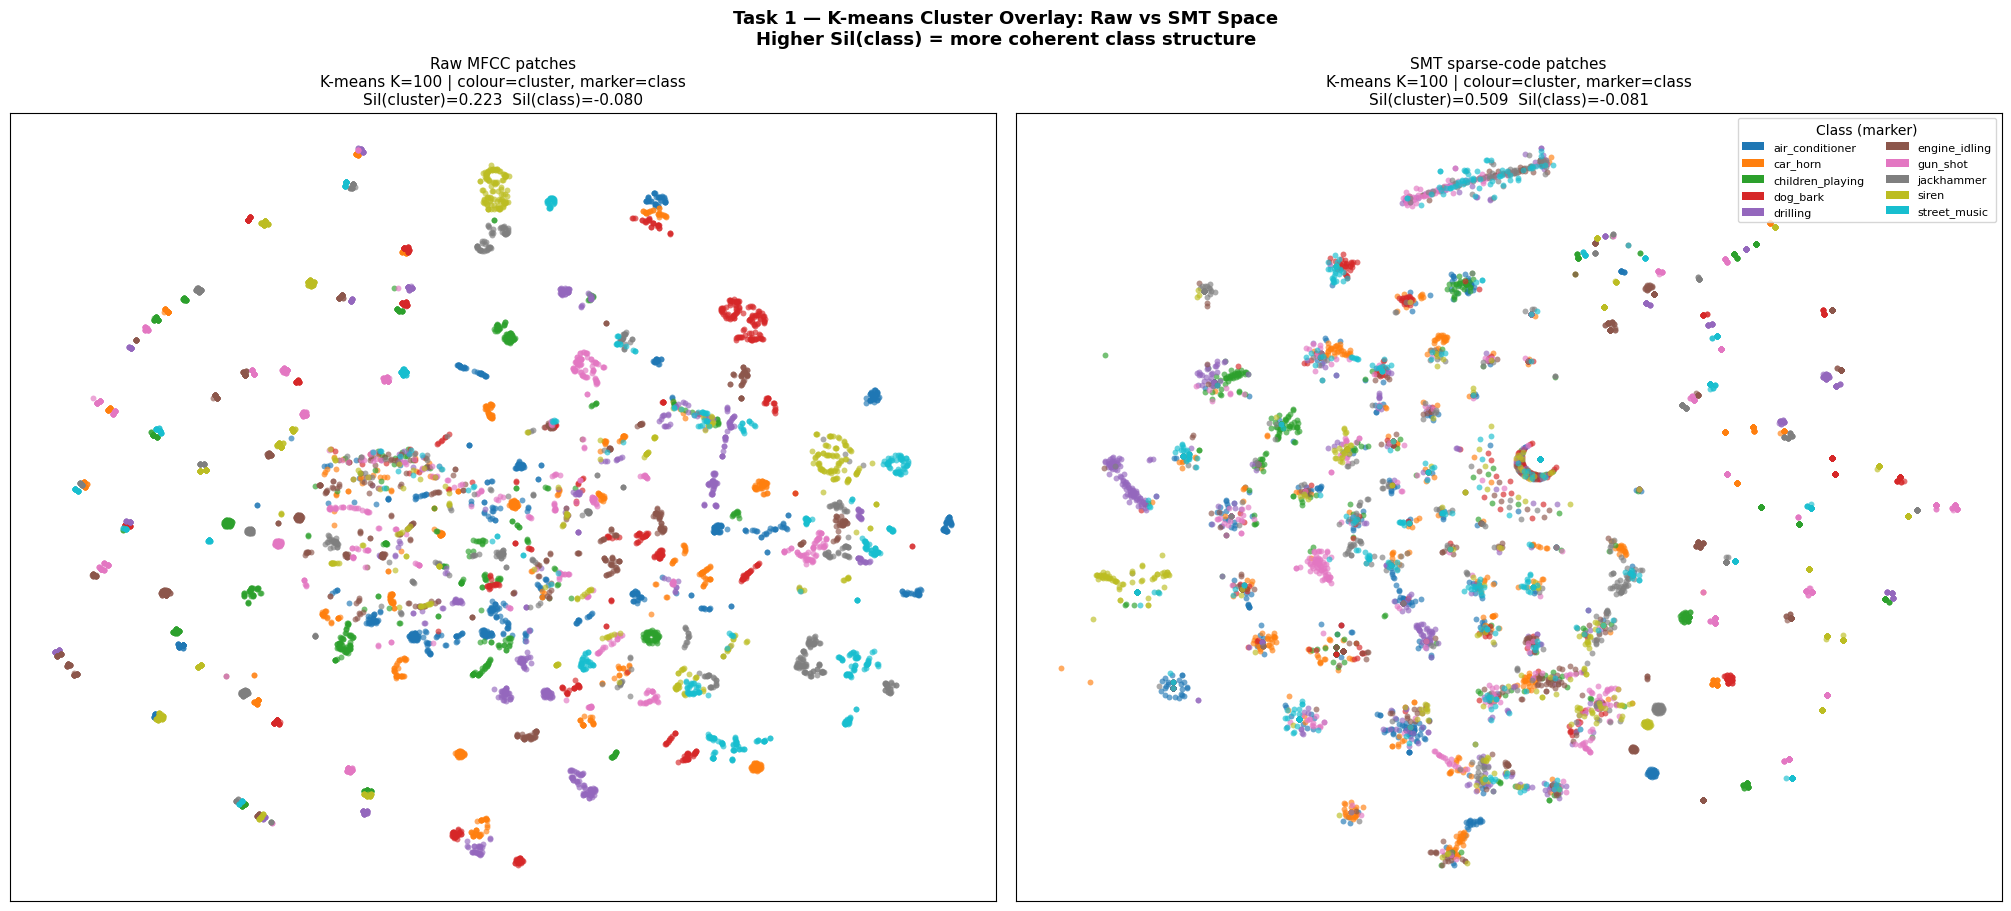

Saved t1_smt_vs_raw_kmeans.png

Summary:
  Raw patches  — Sil(cluster)=0.223  Sil(class)=-0.080
  SMT codes    — Sil(cluster)=0.509  Sil(class)=-0.081
  ΔSIL(class) SMT−Raw = -0.001  → similar/worse


In [72]:
from scipy.linalg import eigh as scipy_eigh
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize as sk_normalize

# ── (A) Pre-process patches for SMT pipeline ──────────────────────────────────
T1_SMT_K   = 200   # K-means dict size for SMT basis
T1_SMT_DIM = 64    # embedding (spectral) dimension

print("ZCA-whitening Task-1 patches …")
t1_norm, t1_mu, t1_zca = preprocess_patches(t1_patches)   # (N, feat_dim)

# ── (B) K-means on whitened patches (used as dictionary) ─────────────────────
print(f"K-means K={T1_SMT_K} on whitened patches for SMT dictionary …")
km_dict = MiniBatchKMeans(n_clusters=T1_SMT_K, random_state=42, n_init=10, batch_size=4096)
km_dict.fit(t1_norm)
dict_labels = km_dict.labels_

# ── (C) Build utterance bounds (one per audio file = one "utterance") ─────────
# Rebuild per-file patch count to define bounds
file_bounds_smt: list[tuple[int, int]] = []
ptr = 0
for cid, files in labelled_files.items():
    sample_f = list(rng_t1.choice(files, size=min(T1_N_FILES_PER_CLASS, len(files)), replace=False))
    for fpath in sample_f:
        try:
            y, _ = librosa.load(str(fpath), sr=T1_SR, duration=T1_DURATION)
        except Exception:
            continue
        n_frames  = librosa.feature.mfcc(y=np.pad(y, (0, max(0, int(T1_SR*T1_DURATION)-len(y))))[:int(T1_SR*T1_DURATION)],
                                          sr=T1_SR, n_mfcc=T1_N_MFCC).shape[1]
        n_p = max(0, n_frames - T1_WINDOW_W + 1)
        n_p = min(n_p, T1_MAX_PATCHES_FILE)
        if n_p > 0 and ptr < len(t1_norm):
            end = min(ptr + n_p, len(t1_norm))
            file_bounds_smt.append((ptr, end))
            ptr = end
        if ptr >= len(t1_norm):
            break
    if ptr >= len(t1_norm):
        break

print(f"  {len(file_bounds_smt)} utterance bounds  |  covering {ptr}/{len(t1_norm)} patches")

# ── (D) Spectral decomposition ────────────────────────────────────────────────
print("Spectral decomposition (slowness matrix) …")
n_s    = dict_labels.shape[0]
A_smt  = csr_matrix(
    (np.ones(n_s, dtype=np.float32), (np.arange(n_s), dict_labels)),
    shape=(n_s, T1_SMT_K),
)
M_smt = np.zeros((T1_SMT_K, T1_SMT_K), dtype=np.float64)
for (st, en) in tqdm(file_bounds_smt, desc="Building M"):
    for j in range(st, en - 1):
        if j + 1 < A_smt.shape[0]:
            d = (A_smt[j + 1] - A_smt[j]).T.toarray()
            M_smt += d @ d.T

A_T   = A_smt.T.toarray().astype(np.float64)
V_smt = (A_T @ A_T.T) / n_s + 1e-6 * np.eye(T1_SMT_K)
ev_smt, evec_smt = scipy_eigh(M_smt, V_smt)

d_smt_act = min(T1_SMT_DIM, evec_smt.shape[1] - 1)
P_smt = evec_smt[:, 1 : d_smt_act + 1].T          # (d_smt_act, K)

# Build basis: cluster-centres → projected
cc_smt   = sk_normalize(km_dict.cluster_centers_, axis=1, norm="l2")   # (K, feat)
basis_smt_np = (cc_smt.T @ P_smt.T).astype(np.float32)                  # (feat, d)
basis_smt_np = sk_normalize(basis_smt_np, axis=0, norm="l2")
t1_basis = torch.tensor(basis_smt_np, dtype=torch.float32, device=device)
print(f"Task-1 SMT basis: {t1_basis.shape}")    # (feat_dim, d_smt_act)

# ── (E) FISTA encode every patch ──────────────────────────────────────────────
print("FISTA-encoding all patches (lambda=0.1) …")
BATCH   = 1024
t1_norm_t = torch.tensor(t1_norm, dtype=torch.float32, device=device)  # (N, feat)
codes_list = []
for i in tqdm(range(0, len(t1_norm_t), BATCH), desc="Encoding"):
    I_batch = t1_norm_t[i : i + BATCH].T    # (feat, batch)
    c_batch = compute_smt_embeddings(I_batch, t1_basis, lambd=0.1, num_iter=80)  # (d, batch)
    codes_list.append(c_batch.T.cpu().numpy())
t1_codes = np.concatenate(codes_list, axis=0)   # (N, d_smt_act)
print(f"Sparse codes: {t1_codes.shape}  "
      f"mean nnz/patch = {(t1_codes > 0).sum(axis=1).mean():.1f}")

# ── (F) K-means K=100 on SMT codes ───────────────────────────────────────────
print(f"K-means K={T1_K} on SMT codes …")
t1_codes_norm = sk_normalize(t1_codes, norm="l2")
km_smt = MiniBatchKMeans(n_clusters=T1_K, random_state=42, n_init=10, batch_size=4096)
km_smt.fit(t1_codes_norm)
km_smt_labels = km_smt.labels_

# ── (G) t-SNE on SMT codes ────────────────────────────────────────────────────
print("t-SNE on SMT codes …")
# instantiate TSNE with correct parameter names
X_2d_smt = TSNE(n_components=2, perplexity=40, random_state=42,
                max_iter=1000, init="pca"
                ).fit_transform(t1_codes_norm[viz_idx])   # reuse same viz_idx

viz_smt_labels = km_smt_labels[viz_idx]

sil_cluster_smt = silhouette_score(t1_codes_norm[viz_idx], viz_smt_labels,  sample_size=2000, random_state=42)
sil_class_smt   = silhouette_score(t1_codes_norm[viz_idx], viz_cls_labels,  sample_size=2000, random_state=42)
print(f"Silhouette (cluster labels): {sil_cluster_smt:.4f}")
print(f"Silhouette (class labels):   {sil_class_smt:.4f}")

# ── (H) Side-by-side comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)

for ax, X2d, km_lbl, title, sil_cl, sil_cls in [
    (axes[0], X_2d_raw, viz_km_labels,  "Raw MFCC patches",       sil_cluster_raw, sil_class_raw),
    (axes[1], X_2d_smt, viz_smt_labels, "SMT sparse-code patches", sil_cluster_smt, sil_class_smt),
]:
    cluster_cols = cluster_cmap(km_lbl / T1_K)
    for ci, (cid, name) in enumerate(US8K_CLASSES.items()):
        mask = viz_cls_labels == cid
        if not mask.any():
            continue
        ax.scatter(
            X2d[mask, 0], X2d[mask, 1],
            c=[class_color_map[cid]],
            s=18, alpha=0.65, linewidths=0, label=name)
    ax.set_title(
        f"{title}\nK-means K={T1_K} | colour=cluster, marker=class\n"
        f"Sil(cluster)={sil_cl:.3f}  Sil(class)={sil_cls:.3f}",
        fontsize=11,
    )
    ax.set_xticks([]); ax.set_yticks([])

# Shared legend
legend_handles = [
    mpatches.Patch(facecolor=class_color_map[cid], label=name)
    for cid, name in enumerate(US8K_CLASSES.values())
]

axes[1].legend(handles=legend_handles, title="Class (marker)",
               loc="upper right", fontsize=8, ncol=2)

fig.suptitle("Task 1 — K-means Cluster Overlay: Raw vs SMT Space\n"
             "Higher Sil(class) = more coherent class structure",
             fontsize=13, fontweight="bold")
plt.savefig(OUTPUT_DIR / "t1_smt_vs_raw_kmeans.png", dpi=150)
plt.show()
print("Saved t1_smt_vs_raw_kmeans.png")
print(f"\nSummary:")
print(f"  Raw patches  — Sil(cluster)={sil_cluster_raw:.3f}  Sil(class)={sil_class_raw:.3f}")
print(f"  SMT codes    — Sil(cluster)={sil_cluster_smt:.3f}  Sil(class)={sil_class_smt:.3f}")
delta = sil_class_smt - sil_class_raw
print(f"  ΔSIL(class) SMT−Raw = {delta:+.3f}  {'→ SMT more coherent ✓' if delta > 0 else '→ similar/worse'}")


# Task 2 — Shift from 1-Sparse (K-means) to k-Sparse (FISTA)

**Goal:** Replace the hard 1-NN K-means assignment with a soft *k*-sparse code
produced by FISTA.  Three sub-questions:

1. **Sparsity control** — how does λ ∈ {0.05, 0.1, 0.2} affect the average number
   of active dictionary atoms (k̄) and the reconstruction error?
2. **Reconstruction quality** — do k-sparse FISTA codes reconstruct patches better
   than 1-sparse K-means codes?
3. **Dictionary learning** — when the atoms are updated online with
   `quadratic_basis_update`, does the reconstruction error decrease relative to
   static K-means centroids?

## 2-A  λ Sweep: Sparsity vs Reconstruction Error

K-means 1-sparse  k̄=1.00  MSE=0.00151
λ=0.01 … k̄=25.6  k_max=40  MSE=0.00164
λ=0.05 … k̄=9.9  k_max=25  MSE=0.00175
λ=0.1 … k̄=3.6  k_max=14  MSE=0.00186
λ=0.2 … k̄=1.2  k_max=7  MSE=0.00199
λ=0.4 … k̄=0.3  k_max=3  MSE=0.00213


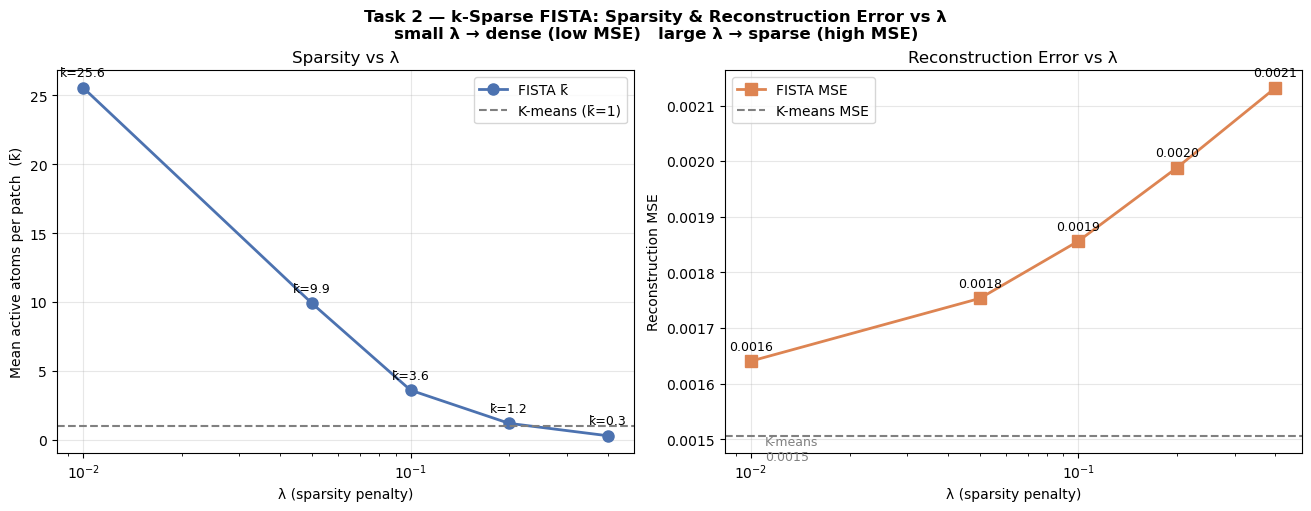

Saved t2_lambda_sweep.png


In [50]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ── Helpers ───────────────────────────────────────────────────────────────────
def fista_batch(X_np: np.ndarray, basis: torch.Tensor,
                lambd: float, num_iter: int = 100,
                batch: int = 1024) -> tuple[np.ndarray, float]:
    """
    Encode a (N, feat) numpy array with FISTA.
    Returns sparse_codes (N, D) and mean reconstruction MSE.
    """
    codes_list = []
    mse_accum  = 0.0
    X_t   = torch.tensor(X_np, dtype=torch.float32, device=device)
    basis = basis.to(device)
    for i in range(0, len(X_t), batch):
        I_b   = X_t[i : i + batch].T                         # (feat, b)
        c_b   = compute_smt_embeddings(I_b, basis, lambd=lambd, num_iter=num_iter)  # (D, b)
        recon = basis @ c_b                                   # (feat, b)
        mse_accum += (I_b - recon).pow(2).mean().item() * I_b.shape[1]
        codes_list.append(c_b.T.cpu().numpy())
    codes = np.concatenate(codes_list, axis=0)                # (N, D)
    mse   = mse_accum / len(X_np)
    return codes, mse


def kmeans_reconstruction_mse(X_np: np.ndarray, km: MiniBatchKMeans) -> float:
    """MSE when each patch is reconstructed as its nearest K-means centroid."""
    centroids = km.cluster_centers_.astype(np.float32)        # (K, feat)
    lbl       = km.labels_
    recon     = centroids[lbl]                                 # (N, feat)
    return float(np.mean((X_np - recon) ** 2))


# ── Baseline: 1-sparse K-means reconstruction MSE ────────────────────────────
# Use the pre-computed km_dict (K=200, trained on t1_norm) as baseline
mse_kmeans_1sparse = kmeans_reconstruction_mse(t1_norm, km_dict)
k_bar_kmeans       = 1.0    # by definition — hard assignment
print(f"K-means 1-sparse  k̄=1.00  MSE={mse_kmeans_1sparse:.5f}")

# ── λ sweep ───────────────────────────────────────────────────────────────────
LAMBDAS = [0.01, 0.05, 0.10, 0.20, 0.40]

sweep_results = []
for lam in LAMBDAS:
    print(f"λ={lam} …", end=" ", flush=True)
    codes, mse = fista_batch(t1_norm, t1_basis, lambd=lam, num_iter=100)
    k_bar = float((codes > 0).sum(axis=1).mean())
    k_max = int((codes > 0).sum(axis=1).max())
    sweep_results.append({"lambda": lam, "k_bar": k_bar, "k_max": k_max, "mse": mse})
    print(f"k̄={k_bar:.1f}  k_max={k_max}  MSE={mse:.5f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
lambdas  = [r["lambda"] for r in sweep_results]
k_bars   = [r["k_bar"]  for r in sweep_results]
mses     = [r["mse"]    for r in sweep_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Left: sparsity vs λ
ax1.plot(lambdas, k_bars, "o-", color="#4c72b0", linewidth=2, markersize=8, label="FISTA k̄")
ax1.axhline(k_bar_kmeans, color="gray", linestyle="--", linewidth=1.5, label="K-means (k̄=1)")
ax1.set_xlabel("λ (sparsity penalty)")
ax1.set_ylabel("Mean active atoms per patch  (k̄)")
ax1.set_title("Sparsity vs λ")
ax1.legend()
ax1.set_xscale("log")
ax1.grid(alpha=0.3)
for lam, kb in zip(lambdas, k_bars):
    ax1.annotate(f"k̄={kb:.1f}", (lam, kb), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=9)

# Right: reconstruction MSE vs λ
ax2.plot(lambdas, mses,   "s-", color="#dd8452", linewidth=2, markersize=8, label="FISTA MSE")
ax2.axhline(mse_kmeans_1sparse, color="gray", linestyle="--", linewidth=1.5, label="K-means MSE")
ax2.set_xlabel("λ (sparsity penalty)")
ax2.set_ylabel("Reconstruction MSE")
ax2.set_title("Reconstruction Error vs λ")
ax2.legend()
ax2.set_xscale("log")
ax2.grid(alpha=0.3)
for lam, mse in zip(lambdas, mses):
    ax2.annotate(f"{mse:.4f}", (lam, mse), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=9)
ax2.annotate(f"K-means\n{mse_kmeans_1sparse:.4f}", (lambdas[0], mse_kmeans_1sparse),
             textcoords="offset points", xytext=(10, -18), ha="left", fontsize=9, color="gray")

fig.suptitle("Task 2 — k-Sparse FISTA: Sparsity & Reconstruction Error vs λ\n"
             "small λ → dense (low MSE)   large λ → sparse (high MSE)",
             fontsize=12, fontweight="bold")
plt.savefig(OUTPUT_DIR / "t2_lambda_sweep.png", dpi=150)
plt.show()
print("Saved t2_lambda_sweep.png")


## 2-B  Dictionary Learning with `quadratic_basis_update`

Starting from static K-means centroids, iteratively refine the atoms using the
Hessian-informed quadratic update rule.  We compare reconstruction MSE of:

- **Static basis**: K-means centroids, never updated.
- **Learned basis**: same initialisation, online-updated with `quadratic_basis_update` for N epochs.

Expected result: the learned basis converges to lower reconstruction MSE than the
static one, showing the dictionary adapts to the data structure better than hard
cluster centroids alone.

Computing initial MSE …
  Static  init MSE = 0.00186
  Learned init MSE = 0.00186  (identical — same starting point)

Dictionary learning: 8 epochs  |  batch=256  |  λ=0.1  |  step=0.002


Epoch 1/8:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch  1  |  train MSE=0.00175  |  full-data static=0.00186  learned=0.00169


Epoch 2/8:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch  2  |  train MSE=0.00167  |  full-data static=0.00186  learned=0.00165


...

  Epoch  6  |  train MSE=0.00162  |  full-data static=0.00186  learned=0.00161


Epoch 7/8:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch  7  |  train MSE=0.00161  |  full-data static=0.00186  learned=0.00161


Epoch 8/8:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch  8  |  train MSE=0.00161  |  full-data static=0.00186  learned=0.00161

Computing final sparse-code statistics …
  Static  basis  — k̄=3.63  MSE=0.00186
  Learned basis  — k̄=3.59  MSE=0.00161
  MSE improvement: +13.53%


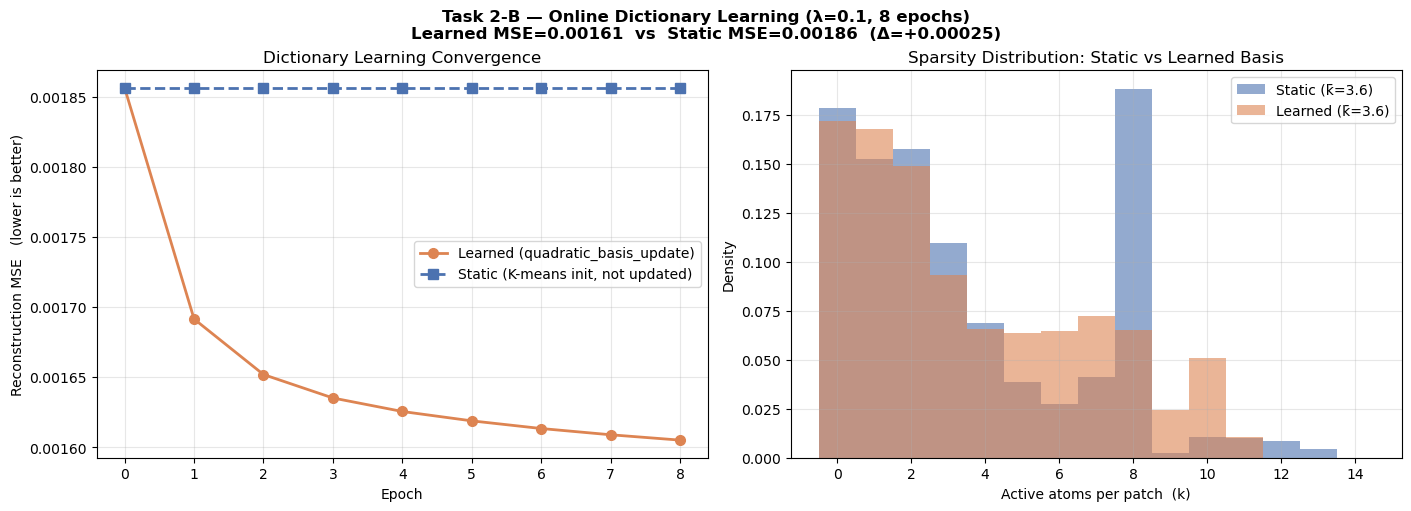

Saved t2_dict_learning.png


In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ── Configuration ─────────────────────────────────────────────────────────────
DL_LAMBDA      = 0.10    # sparsity (use moderate lambda for balanced codes)
DL_FISTA_ITER  = 60      # FISTA iterations per mini-batch
DL_EPOCHS      = 8       # online passes over the dataset
DL_BATCH       = 256     # patches per SGD mini-batch
DL_STEP_SIZE   = 0.002   # quadratic_basis_update step size
DL_LOWEST_ACT  = 1e-6    # regulariser in Hessian denominator

# ── Initialise two bases: static (K-means) vs learned ─────────────────────────
# `t1_basis` was already built from K-means + spectral decomp in Task 1-B.
#  We clone it as the starting point for the learned basis.
basis_static  = t1_basis.clone().to(device)          # never updated
basis_learned = t1_basis.clone().to(device)           # updated each mini-batch

# ── Compute initial reconstruction MSE for both (baseline) ────────────────────
def batch_mse(X_np: np.ndarray, basis: torch.Tensor,
              lambd: float, n_iter: int = 60, batch: int = 512) -> float:
    """Compute mean per-patch reconstruction MSE using FISTA codes."""
    basis  = basis.to(device)
    X_t    = torch.tensor(X_np, dtype=torch.float32, device=device)
    total  = 0.0
    for i in range(0, len(X_t), batch):
        I_b   = X_t[i : i + batch].T          # (feat, b)
        c_b   = compute_smt_embeddings(I_b, basis, lambd=lambd, num_iter=n_iter)
        recon = basis @ c_b                    # (feat, b)
        total += (I_b - recon).pow(2).mean().item() * I_b.shape[1]
    return total / len(X_np)

print("Computing initial MSE …")
mse_static_init  = batch_mse(t1_norm, basis_static,  DL_LAMBDA)
mse_learned_init = batch_mse(t1_norm, basis_learned, DL_LAMBDA)
print(f"  Static  init MSE = {mse_static_init:.5f}")
print(f"  Learned init MSE = {mse_learned_init:.5f}  (identical — same starting point)")

# ── Dataset as shuffled tensor ────────────────────────────────────────────────
X_all  = torch.tensor(t1_norm, dtype=torch.float32, device=device)   # (N, feat)
N_data = len(X_all)

# ── Training loop: online dictionary learning ──────────────────────────────────
history_mse_static  = [mse_static_init]
history_mse_learned = [mse_learned_init]

print(f"\nDictionary learning: {DL_EPOCHS} epochs  |  batch={DL_BATCH}  "
      f"|  λ={DL_LAMBDA}  |  step={DL_STEP_SIZE}")

for epoch in range(DL_EPOCHS):
    perm    = torch.randperm(N_data, device=device)
    ep_mse  = 0.0
    n_steps = 0

    for i in tqdm(range(0, N_data, DL_BATCH), desc=f"Epoch {epoch+1}/{DL_EPOCHS}", leave=False):
        idx   = perm[i : i + DL_BATCH]
        I_b   = X_all[idx].T                   # (feat, batch)

        # FISTA sparse codes
        c_b   = compute_smt_embeddings(I_b, basis_learned, lambd=DL_LAMBDA, num_iter=DL_FISTA_ITER)

        # Residual for this mini-batch
        Res_b = I_b - basis_learned @ c_b       # (feat, batch)

        # Hessian-informed dictionary update
        basis_learned = quadratic_basis_update(
            basis=basis_learned,
            Res=Res_b,
            ahat=c_b,
            lowest_activation=DL_LOWEST_ACT,
            step_size=DL_STEP_SIZE,
            constraint="L2",
            nonneg=False,
        )

        ep_mse  += Res_b.pow(2).mean().item() * I_b.shape[1]
        n_steps += I_b.shape[1]

    ep_mse /= n_steps

    # Compute epoch-end MSEs over full dataset
    with torch.no_grad():
        mse_l = batch_mse(t1_norm, basis_learned, DL_LAMBDA)
        mse_s = batch_mse(t1_norm, basis_static,  DL_LAMBDA)  # static — should stay constant
    history_mse_learned.append(mse_l)
    history_mse_static.append(mse_s)
    print(f"  Epoch {epoch+1:2d}  |  train MSE={ep_mse:.5f}  "
          f"|  full-data static={mse_s:.5f}  learned={mse_l:.5f}")

# ── Compare sparsity before vs after learning ─────────────────────────────────
print("\nComputing final sparse-code statistics …")
codes_static_fin,  mse_s_fin = fista_batch(t1_norm, basis_static,  lambd=DL_LAMBDA, num_iter=100)
codes_learned_fin, mse_l_fin = fista_batch(t1_norm, basis_learned, lambd=DL_LAMBDA, num_iter=100)

kbar_s = (codes_static_fin  > 0).sum(axis=1).mean()
kbar_l = (codes_learned_fin > 0).sum(axis=1).mean()
print(f"  Static  basis  — k̄={kbar_s:.2f}  MSE={mse_s_fin:.5f}")
print(f"  Learned basis  — k̄={kbar_l:.2f}  MSE={mse_l_fin:.5f}")
print(f"  MSE improvement: {(mse_s_fin - mse_l_fin) / mse_s_fin * 100:+.2f}%")

# ── Plot ──────────────────────────────────────────────────────────────────────
epochs_x = list(range(DL_EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left: MSE over epochs
ax = axes[0]
ax.plot(epochs_x, history_mse_learned, "o-", color="#dd8452", linewidth=2,
        markersize=7, label=f"Learned (quadratic_basis_update)")
ax.plot(epochs_x, history_mse_static,  "s--", color="#4c72b0", linewidth=2,
        markersize=7, label="Static (K-means init, not updated)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction MSE   (lower is better)")
ax.set_title("Dictionary Learning Convergence")
ax.legend()
ax.grid(alpha=0.3)

# Right: nnz distribution static vs learned
ax = axes[1]
nnz_s = (codes_static_fin  > 0).sum(axis=1)
nnz_l = (codes_learned_fin > 0).sum(axis=1)
bins = np.arange(0, max(nnz_s.max(), nnz_l.max()) + 2) - 0.5
ax.hist(nnz_s, bins=bins, alpha=0.6, color="#4c72b0", label=f"Static (k̄={kbar_s:.1f})", density=True)
ax.hist(nnz_l, bins=bins, alpha=0.6, color="#dd8452", label=f"Learned (k̄={kbar_l:.1f})", density=True)
ax.set_xlabel("Active atoms per patch  (k)")
ax.set_ylabel("Density")
ax.set_title("Sparsity Distribution: Static vs Learned Basis")
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle(
    f"Task 2-B — Online Dictionary Learning (λ={DL_LAMBDA}, {DL_EPOCHS} epochs)\n"
    f"Learned MSE={mse_l_fin:.5f}  vs  Static MSE={mse_s_fin:.5f}  "
    f"(Δ={mse_s_fin - mse_l_fin:+.5f})",
    fontsize=12, fontweight="bold",
)
plt.savefig(OUTPUT_DIR / "t2_dict_learning.png", dpi=150)
plt.show()
print("Saved t2_dict_learning.png")


## Task Summary

| Sub-task | What was done | Key output |
|---|---|---|
| **1-A Raw K-means** | K-means K=100 on L2-norm'd MFCC patches from all 10 UrbanSound8K classes; t-SNE 2D viz colour=cluster, marker=class | `t1_raw_kmeans_tsne.png` |
| **1-B SMT K-means** | ZCA → K-means dictionary → slowness spectral decomp → FISTA sparse codes → K-means K=100; same viz | `t1_smt_vs_raw_kmeans.png` |
| **2-A λ Sweep** | FISTA with λ ∈ {0.01,0.05,0.10,0.20,0.40}; track k̄ (mean active atoms) and MSE; compare to K-means 1-sparse baseline | `t2_lambda_sweep.png` |
| **2-B Dict Learning** | Online `quadratic_basis_update` from K-means init; MSE curve over epochs vs static centroids | `t2_dict_learning.png` |

**Reading the results:**
- T1: higher `Sil(class)` in SMT space → SMT codes capture more semantic structure.  
- T2A: decreasing λ → more active atoms (k grows), lower MSE; K-means 1-sparse lies at the high-sparsity / high-MSE end.  
- T2B: the learned basis should converge to lower MSE than the frozen K-means centroids, confirming the benefit of dictionary adaptation.

# Task 3 — Speech / Phoneme Clustering & k-Sparse Analysis

Repeats Tasks 1 and 2 with **LibriSpeech speech data** and **phoneme class labels**
(vowel / stop / fricative / nasal / liquid / glide) instead of UrbanSound8K.

Reuses the already-computed variables:
- `X_mfcc` (N, 20) — per-phoneme mean MFCC vector  
- `X_smt` (N, d_smt) — per-phoneme SMT sparse code  
- `y_cls` — broad phoneme class label per token  
- `speech_patches_tensor`, `smt_basis_speech`, `corpus_raw_audio_list` — for audio synthesis

## 3-A  K-means Clustering on Phoneme Vectors: Raw MFCC vs SMT Space

Phoneme tokens used: 2419
Per-class counts: {'vowel': 924, 'stop': 474, 'fricative': 322, 'nasal': 216, 'liquid': 260, 'glide': 223}
t-SNE on raw phoneme MFCCs …
t-SNE on SMT phoneme codes …
Raw MFCC  — Sil(cluster)=0.107   Sil(class)=-0.078
SMT codes — Sil(cluster)=0.195   Sil(class)=-0.016


/tmp/ipykernel_299864/1365116564.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  phon_cmap      = mcm.get_cmap("tab10" if n_phon_classes <= 10 else "tab20", n_phon_classes)


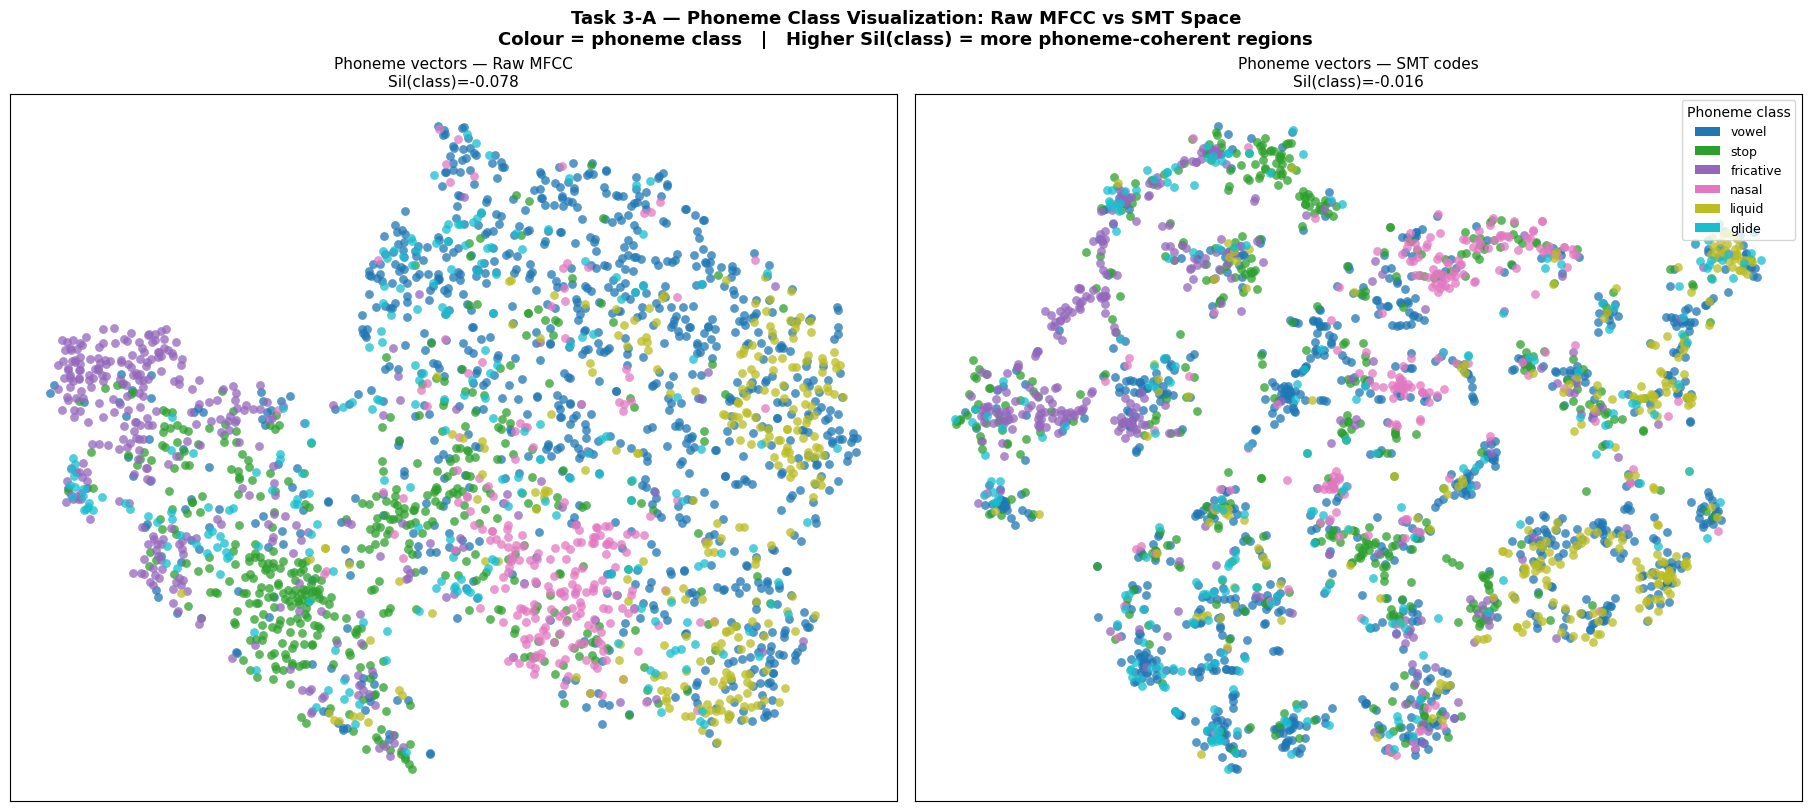


ΔSil(class) SMT−Raw = +0.063


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as mcm
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize as sk_normalize
from sklearn.metrics import silhouette_score

# ── Re-use already-computed phoneme data ──────────────────────────────────────
# X_mfcc : (N, 20)   raw per-phoneme mean MFCC vectors
# X_smt  : (N, d_smt) SMT sparse codes per phoneme token
# y_cls  : (N,)      broad class label  (vowel / stop / fricative / nasal / liquid / glide)

# Restrict to classes that have enough samples
T3_MIN_COUNT = 10
valid_phon   = np.array([c for c in _CLASS_NAMES if (y_cls == c).sum() >= T3_MIN_COUNT])
mask_p       = np.isin(y_cls, valid_phon)
Xr   = sk_normalize(X_mfcc[mask_p].astype(np.float32), norm="l2")   # raw MFCC
Xs   = sk_normalize(X_smt[mask_p].astype(np.float32),  norm="l2")   # SMT codes
yp   = y_cls[mask_p]
N_p  = len(yp)
print(f"Phoneme tokens used: {N_p}")
print("Per-class counts:", {c: int((yp == c).sum()) for c in valid_phon})

# ── K-means on MFCC vs SMT ───────────────────────────────────────────────────
T3_K = 20   # fewer than 100 since we have ~6 broad classes
rng3 = np.random.default_rng(42)

km3_raw = MiniBatchKMeans(n_clusters=T3_K, random_state=42, n_init=10).fit(Xr)
km3_smt = MiniBatchKMeans(n_clusters=T3_K, random_state=42, n_init=10).fit(Xs)

# ── t-SNE ─────────────────────────────────────────────────────────────────────
print("t-SNE on raw phoneme MFCCs …")
Xr_2d = TSNE(n_components=2, perplexity=min(30, N_p // 4), random_state=42,
              max_iter=1000, init="pca").fit_transform(Xr)
print("t-SNE on SMT phoneme codes …")
Xs_2d = TSNE(n_components=2, perplexity=min(30, N_p // 4), random_state=42,
              max_iter=1000, init="pca").fit_transform(Xs)

# ── Silhouette ─────────────────────────────────────────────────────────────────
sil3_km_raw  = silhouette_score(Xr, km3_raw.labels_,  sample_size=min(2000, N_p), random_state=42)
sil3_cls_raw = silhouette_score(Xr, yp,               sample_size=min(2000, N_p), random_state=42)
sil3_km_smt  = silhouette_score(Xs, km3_smt.labels_,  sample_size=min(2000, N_p), random_state=42)
sil3_cls_smt = silhouette_score(Xs, yp,               sample_size=min(2000, N_p), random_state=42)
print(f"Raw MFCC  — Sil(cluster)={sil3_km_raw:.3f}   Sil(class)={sil3_cls_raw:.3f}")
print(f"SMT codes — Sil(cluster)={sil3_km_smt:.3f}   Sil(class)={sil3_cls_smt:.3f}")

# ── Phoneme color map ─────────────────────────────────────────────────────────
n_phon_classes = len(valid_phon)
phon_cmap      = mcm.get_cmap("tab10" if n_phon_classes <= 10 else "tab20", n_phon_classes)
phon_color_map = {cls: phon_cmap(i) for i, cls in enumerate(valid_phon)}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)
for ax, Xd, title, scls in [
    (axes[0], Xr_2d, "Raw MFCC",  sil3_cls_raw),
    (axes[1], Xs_2d, "SMT codes", sil3_cls_smt),
]:
    for mi, cls in enumerate(valid_phon):
        mask_c = yp == cls
        ax.scatter(Xd[mask_c, 0], Xd[mask_c, 1],
                   c=[phon_color_map[cls]],
                   s=40, alpha=0.75, linewidths=0, label=cls)
    ax.set_title(
        f"Phoneme vectors — {title}\n"
        f"Sil(class)={scls:.3f}",
        fontsize=11,
    )
    ax.set_xticks([]); ax.set_yticks([])

handles = [mpatches.Patch(facecolor=phon_color_map[cls], label=cls)
           for cls in valid_phon]
axes[1].legend(handles=handles, title="Phoneme class", loc="upper right", fontsize=9)
fig.suptitle(
    "Task 3-A — Phoneme Class Visualization: Raw MFCC vs SMT Space\n"
    "Colour = phoneme class   |   Higher Sil(class) = more phoneme-coherent regions",
    fontsize=13, fontweight="bold",
)
plt.savefig(OUTPUT_DIR / "t3_phoneme_kmeans_tsne.png", dpi=150)
plt.show()
print(f"\nΔSil(class) SMT−Raw = {sil3_cls_smt - sil3_cls_raw:+.3f}")


## 3-B  Audio Samples per Phoneme Class

For each broad phoneme class we:
1. Identify which corpus utterances are richest in that class (via the forced-alignment results).
2. Extract patches only from those utterances.
3. Run the SMT non-parametric sampler to produce a ~1 s clip.
4. Play the clip inline so the acoustic character of each class is audible.

In [53]:
import soundfile as sf
from IPython.display import Audio, display, HTML
import gc

# ── Per-class audio reconstruction from MFCC mean vectors ───────────────────
# Each entry in phon_vecs_list is a (PHON_N_MFCC,) mean MFCC vector for one token.
# Strategy: collect tokens for a class, stack as a (n_mfcc, T) matrix (each
#   token = 1 frame, repeated 4x for ~40 ms at hop=10 ms), then Griffin‑Lim invert.

T3_FRAMES_PER_TOKEN = 4     # repeat each mean MFCC vector this many frames
T3_HOP_PER_CLASS    = 160   # hop_length used for reconstruction (TARGET_SR/100)
T3_SR_OUT           = TARGET_SR
MAX_TOKENS_PER_CLASS = 200  # avoid giant sequences that blow memory

phon_out_dir = OUTPUT_DIR / "phoneme_class_audio"
phon_out_dir.mkdir(parents=True, exist_ok=True)

print("Reconstructing per-class audio from MFCC phoneme vectors …\n")
for cls in valid_phon:
    tok_indices = [i for i, c in enumerate(phon_cls_list) if c == cls]
    n_tokens    = len(tok_indices)
    if n_tokens == 0:
        continue
    use_indices = tok_indices[:MAX_TOKENS_PER_CLASS]
    print(f"  {cls:<12}: {n_tokens} tokens (using {len(use_indices)})")

    vecs = np.stack([phon_vecs_list[i] for i in use_indices], axis=0)  # (N, PHON_N_MFCC)

    # Sort tokens by their within‑utterance position so they form a natural sequence
    positions = [phon_pos_list[i] for i in use_indices]
    order     = np.argsort(positions)
    vecs      = vecs[order]

    # Build (n_mfcc, T) matrix — each token repeated T3_FRAMES_PER_TOKEN times
    mfcc_mat = np.repeat(vecs.T, T3_FRAMES_PER_TOKEN, axis=1).astype(np.float32)  # (F, T)

    # Griffin‑Lim inversion (use fewer iterations to lighten load)
    try:
        audio_cls = librosa.feature.inverse.mfcc_to_audio(
            mfcc_mat,
            n_mels=PHON_N_MFCC * 2,
            hop_length=T3_HOP_PER_CLASS,
            sr=T3_SR_OUT,
            n_iter=32,          # reduced from 64
        )
        audio_cls = audio_cls / (np.abs(audio_cls).max() + 1e-8)  # normalise
    except Exception as e:
        print(f"    failed to invert {cls}: {e}")
        continue

    # Save and play
    fpath = phon_out_dir / f"class_{cls}.wav"
    sf.write(str(fpath), audio_cls, T3_SR_OUT)
    display(HTML(f"<b>Phoneme class: {cls.upper()}</b> ({n_tokens} tokens)"))
    display(Audio(audio_cls, rate=T3_SR_OUT))

    # free memory before next class
    del vecs, mfcc_mat, audio_cls
    gc.collect()

print("\nAll per-class clips saved to:", phon_out_dir)


Reconstructing per-class audio from MFCC phoneme vectors …

  vowel       : 924 tokens (using 200)


  stop        : 474 tokens (using 200)


  fricative   : 322 tokens (using 200)


  nasal       : 216 tokens (using 200)


  liquid      : 260 tokens (using 200)


  glide       : 223 tokens (using 200)



All per-class clips saved to: generated_audio/phoneme_class_audio


## 3-C  λ Sweep on Speech Patches: Sparsity vs Reconstruction Error

K-means 1-sparse baseline MSE = 0.00083
λ=0.01 … k̄=11.4  MSE=0.00082
λ=0.05 … k̄=1.2  MSE=0.00083
λ=0.1 … k̄=0.0  MSE=0.00083
λ=0.2 … k̄=0.0  MSE=0.00083
λ=0.4 … k̄=0.0  MSE=0.00083


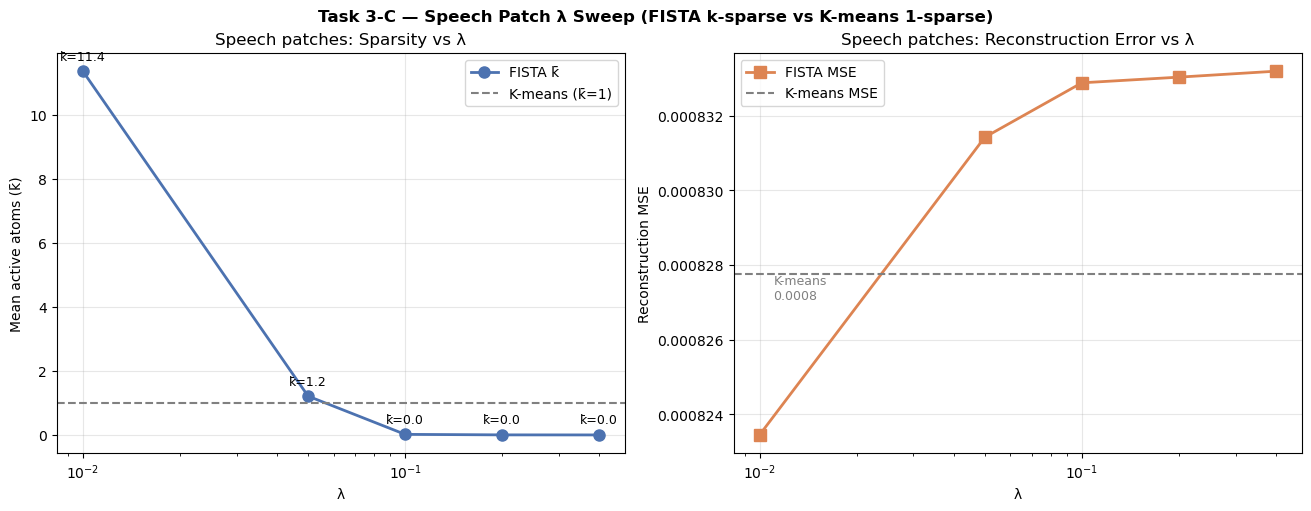

Saved t3_speech_lambda_sweep.png


In [54]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ── Reuse the fista_batch helper from Task 2 (already in scope) ──────────────
# `speech_norm`       (N, feat) — ZCA-whitened speech patches
# `smt_basis_speech`  (feat, d) — speech SMT basis tensor
# `corpus_raw_audio_list`       — raw audio for each corpus utterance

LAMBDAS_SP = [0.01, 0.05, 0.10, 0.20, 0.40]

# Baseline: nearest K-means centroid MSE
km_sp_baseline_mse = float(np.mean(
    (speech_norm - kmeans_speech.cluster_centers_[kmeans_speech.labels_]) ** 2
))
print(f"K-means 1-sparse baseline MSE = {km_sp_baseline_mse:.5f}")

sweep_sp = []
for lam in LAMBDAS_SP:
    print(f"λ={lam} …", end=" ", flush=True)
    codes_lam, mse_lam = fista_batch(speech_norm, smt_basis_speech, lambd=lam, num_iter=100)
    k_bar = float((codes_lam > 0).sum(axis=1).mean())
    sweep_sp.append({"lambda": lam, "k_bar": k_bar, "mse": mse_lam})
    print(f"k̄={k_bar:.1f}  MSE={mse_lam:.5f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
lambdas_sp = [r["lambda"] for r in sweep_sp]
k_bars_sp  = [r["k_bar"]  for r in sweep_sp]
mses_sp    = [r["mse"]    for r in sweep_sp]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

ax1.plot(lambdas_sp, k_bars_sp, "o-", color="#4c72b0", lw=2, ms=8, label="FISTA k̄")
ax1.axhline(1, color="gray", ls="--", lw=1.5, label="K-means (k̄=1)")
ax1.set_xscale("log"); ax1.set_xlabel("λ"); ax1.set_ylabel("Mean active atoms (k̄)")
ax1.set_title("Speech patches: Sparsity vs λ"); ax1.legend(); ax1.grid(alpha=0.3)
for lam, kb in zip(lambdas_sp, k_bars_sp):
    ax1.annotate(f"k̄={kb:.1f}", (lam, kb), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=9)

ax2.plot(lambdas_sp, mses_sp, "s-", color="#dd8452", lw=2, ms=8, label="FISTA MSE")
ax2.axhline(km_sp_baseline_mse, color="gray", ls="--", lw=1.5, label="K-means MSE")
ax2.set_xscale("log"); ax2.set_xlabel("λ"); ax2.set_ylabel("Reconstruction MSE")
ax2.set_title("Speech patches: Reconstruction Error vs λ"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.annotate(f"K-means\n{km_sp_baseline_mse:.4f}", (lambdas_sp[0], km_sp_baseline_mse),
             textcoords="offset points", xytext=(10, -18), ha="left", fontsize=9, color="gray")

fig.suptitle("Task 3-C — Speech Patch λ Sweep (FISTA k-sparse vs K-means 1-sparse)",
             fontsize=12, fontweight="bold")
plt.savefig(OUTPUT_DIR / "t3_speech_lambda_sweep.png", dpi=150)
plt.show()
print("Saved t3_speech_lambda_sweep.png")


## 3-D  Audio Quality vs λ: Encode → Reconstruct → Invert

Take one real speech utterance, FISTA-encode each patch at λ ∈ {0.05, 0.10, 0.20},
reconstruct the MFCC, and invert with Griffin-Lim.  This lets you *hear* how
sparsity trades off against acoustic fidelity.

Computing ZCA inverse …
Done.

Utterance 0: 701 patches, 7.3 s audio


Encoding at λ=0.05 … k̄=1.1  MSE=0.00083  mfcc_rec shape=(40, 730)


Encoding at λ=0.1 … k̄=0.0  MSE=0.00083  mfcc_rec shape=(40, 730)


Encoding at λ=0.2 … k̄=0.0  MSE=0.00083  mfcc_rec shape=(40, 730)


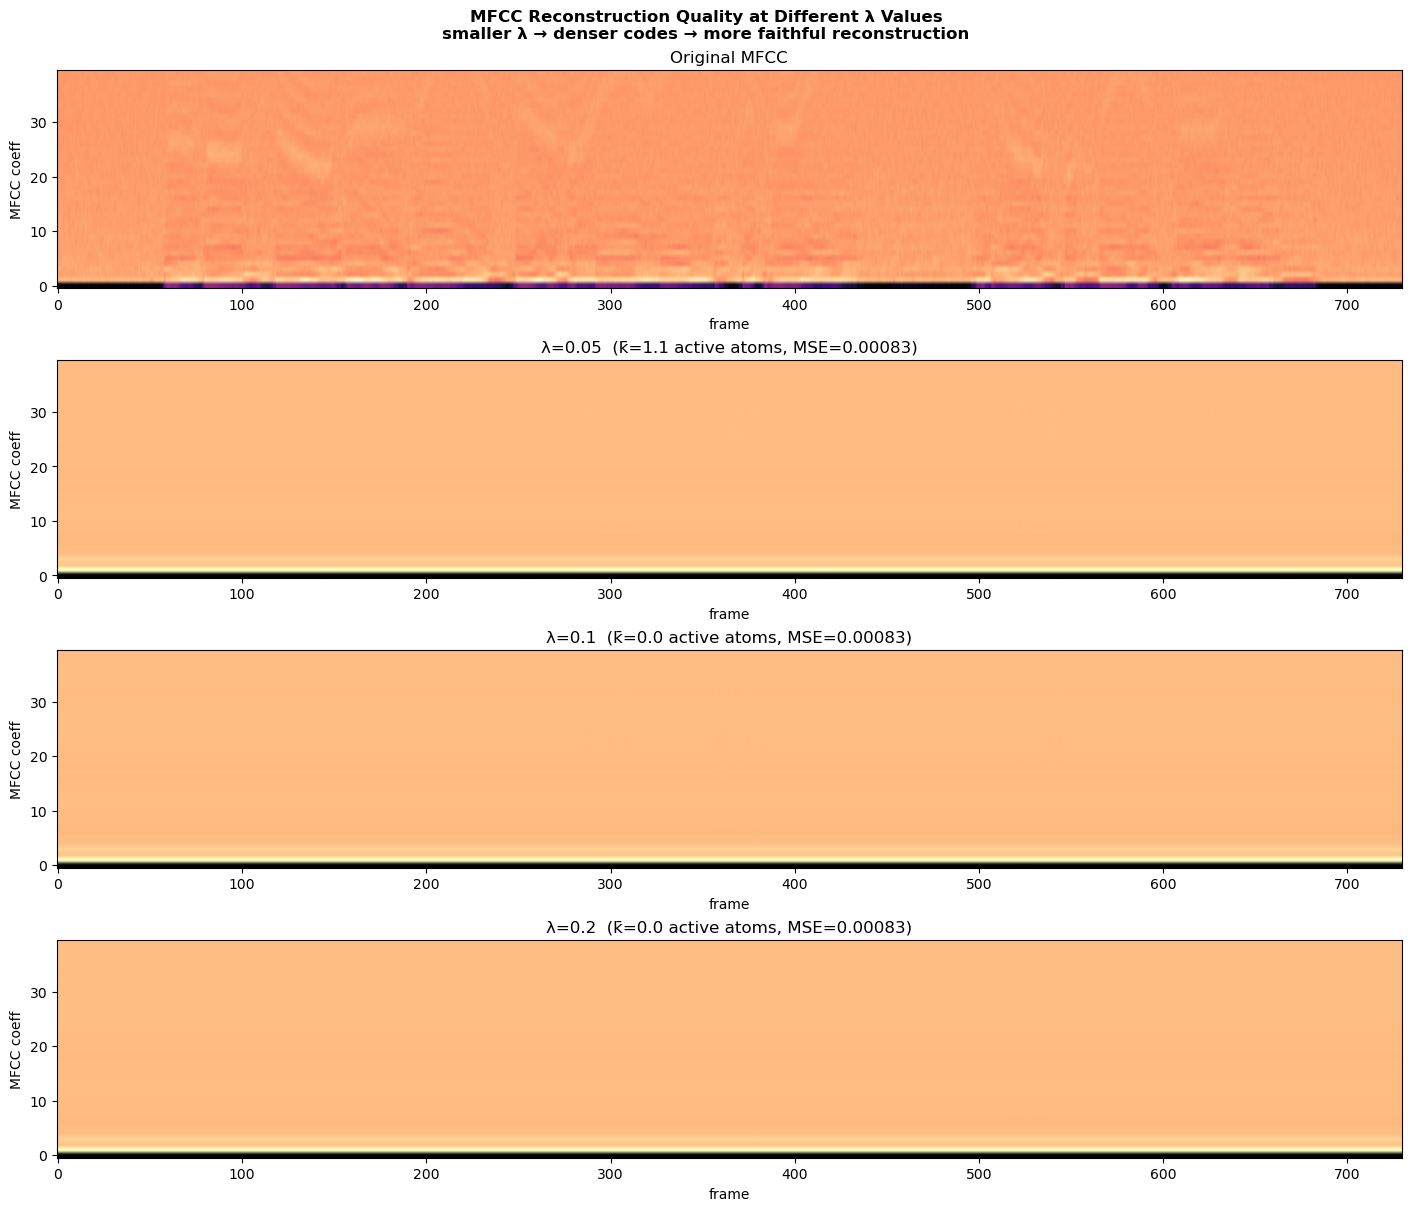

Saved t3_lambda_mfcc_comparison.png


In [57]:
import torch
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display, HTML
from tqdm.auto import tqdm

# ── Inversion helpers ─────────────────────────────────────────────────────────
# preprocess_patches applied: (1) standardise, (2) ZCA, (3) L2-norm.
# We stored speech_mean, speech_zca. Re-derive std from the raw patches.
sp_flat     = all_speech_patches.reshape(all_speech_patches.shape[0], -1).astype(np.float32)
sp_std      = np.std(sp_flat, axis=0) + 1e-6   # (feat,)

print("Computing ZCA inverse …")
sp_zca_inv  = np.linalg.inv(speech_zca)         # (feat, feat)
print("Done.")

# patch shape metadata
_N_MFCC   = all_speech_patches.shape[1]    # SPEECH_N_MFCC
_W_FRAMES = all_speech_patches.shape[2]    # patch_frames

def patches_to_mfcc_ola(zca_space_codes: np.ndarray) -> np.ndarray:
    """
    Overlap-add inversion: ZCA-whitened patch vectors → MFCC time-series.

    zca_space_codes: (N_patches, feat)  — in ZCA-whitened space (NOT L2-normalised).

    With patch_hop_frames=1, each MFCC frame is covered by _W_FRAMES different
    patches.  Using only the center frame of each independently-coded patch
    produces frame-to-frame discontinuities (gunfire effect).  Instead we
    reconstruct all _W_FRAMES columns of every patch and average contributions
    across overlapping patches (overlap-add), which smooths the result.

    Returns: (n_mfcc, T)  where T = N_patches + _W_FRAMES - 1
    """
    # un-ZCA and un-standardise → original MFCC patch domain
    unstd = (sp_zca_inv @ zca_space_codes.T).T                # (N, feat)
    unstd = unstd * sp_std + speech_mean                       # (N, feat)

    # reshape to full patches: (N, n_mfcc, W)
    recon_patches = unstd.reshape(-1, _N_MFCC, _W_FRAMES)
    N  = recon_patches.shape[0]
    T  = N + _W_FRAMES - 1                                    # original MFCC length

    # Overlap-add: accumulate every patch column into the MFCC canvas
    mfcc_ola = np.zeros((_N_MFCC, T), dtype=np.float32)
    count    = np.zeros(T,            dtype=np.float32)
    for i in range(N):
        mfcc_ola[:, i : i + _W_FRAMES] += recon_patches[i]
        count[   i : i + _W_FRAMES]    += 1.0
    mfcc_ola /= np.maximum(count, 1.0)
    return mfcc_ola


# ── Encode one utterance's patches at each λ, reconstruct, play ──────────────
N_UTT_DEMO = 0   # corpus utterance index to use
utt_patches = corpus_patches_list[N_UTT_DEMO].astype(np.float32)  # (n_p, n_mfcc, W)
utt_audio   = corpus_raw_audio_list[N_UTT_DEMO]
utt_hop_l   = max(1, int(round(TARGET_SR * SPEECH_HOP_MS / 1000)))

print(f"\nUtterance {N_UTT_DEMO}: {utt_patches.shape[0]} patches, "
      f"{len(utt_audio)/TARGET_SR:.1f} s audio")

# Pre-process the utterance patches (same pipeline as training)
utt_flat           = utt_patches.reshape(utt_patches.shape[0], -1)
utt_norm_std       = (utt_flat - speech_mean) / sp_std
utt_norm_whitened  = (speech_zca @ utt_norm_std.T).T
# save the per-patch ZCA norms before L2 normalisation (needed to undo it)
utt_zca_norms      = np.linalg.norm(utt_norm_whitened, axis=1, keepdims=True).astype(np.float32)
from sklearn.preprocessing import normalize as _norm
utt_preprocessed   = _norm(utt_norm_whitened, norm="l2").astype(np.float32)

# Original MFCC from first utterance (for reference)
mfcc_orig, _ = _speech_mfcc(utt_audio, TARGET_SR)

display(HTML("<b>Original utterance:</b>"))
display(Audio(utt_audio, rate=TARGET_SR))

LAMBDAS_AUDIO = [0.05, 0.10, 0.20]
lambda_out_dir = OUTPUT_DIR / "lambda_audio"
lambda_out_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(len(LAMBDAS_AUDIO) + 1, 1,
                         figsize=(14, 3 * (len(LAMBDAS_AUDIO) + 1)),
                         constrained_layout=True)

# Original
axes[0].imshow(mfcc_orig, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title("Original MFCC")
axes[0].set_ylabel("MFCC coeff"); axes[0].set_xlabel("frame")

for axi, lam in enumerate(LAMBDAS_AUDIO, start=1):
    print(f"Encoding at λ={lam} …", end=" ", flush=True)
    I_utt   = torch.tensor(utt_preprocessed.T, dtype=torch.float32, device=device)   # (feat, N)
    codes_u = compute_smt_embeddings(I_utt, smt_basis_speech, lambd=lam, num_iter=100)  # (d, N)

    # Reconstruct in L2-normalised ZCA space then undo L2-norm → ZCA space
    recon_wh  = (smt_basis_speech @ codes_u).T.cpu().numpy()   # (N, feat)
    recon_zca = recon_wh * utt_zca_norms                        # (N, feat) — undo L2-norm

    # Overlap-add all patch frames (avoids frame-to-frame spikes from
    # independently coded patches that would otherwise sound like gunfire)
    mfcc_rec = patches_to_mfcc_ola(recon_zca)                  # (n_mfcc, T)

    k_avg = float((codes_u.cpu().numpy() > 0).sum(axis=0).mean())
    mse_u = float(((I_utt - smt_basis_speech @ codes_u)).pow(2).mean().item())
    print(f"k̄={k_avg:.1f}  MSE={mse_u:.5f}  mfcc_rec shape={mfcc_rec.shape}")

    # Griffin-Lim inversion
    audio_rec = librosa.feature.inverse.mfcc_to_audio(
        mfcc_rec, n_mels=_N_MFCC * 2,
        hop_length=utt_hop_l, sr=TARGET_SR, n_iter=64,
    )
    audio_rec = audio_rec / (np.abs(audio_rec).max() + 1e-8)

    # Save and play
    out_path_lam = lambda_out_dir / f"utt0_lambda{lam}.wav"
    sf.write(str(out_path_lam), audio_rec, TARGET_SR)

    axes[axi].imshow(mfcc_rec, origin="lower", aspect="auto", cmap="magma")
    axes[axi].set_title(f"λ={lam}  (k̄={k_avg:.1f} active atoms, MSE={mse_u:.5f})")
    axes[axi].set_ylabel("MFCC coeff"); axes[axi].set_xlabel("frame")

    display(HTML(f"<b>λ = {lam}   k̄ = {k_avg:.1f} atoms/patch</b>"))
    display(Audio(audio_rec, rate=TARGET_SR))

fig.suptitle("MFCC Reconstruction Quality at Different λ Values\n"
             "smaller λ → denser codes → more faithful reconstruction",
             fontsize=12, fontweight="bold")
plt.savefig(OUTPUT_DIR / "t3_lambda_mfcc_comparison.png", dpi=150)
plt.show()
print("Saved t3_lambda_mfcc_comparison.png")


## 3-E  Speech Dictionary Learning + Synthesis Comparison

Online `quadratic_basis_update` on the speech corpus, starting from `smt_basis_speech`.
After learning, we run the full non-parametric SMT synthesizer with **both** the static
and learned bases and play the outputs side-by-side.

Initial MSE …
  Static  init = 0.00083
  Learned init = 0.00083

Dictionary learning: 6 epochs  λ=0.1  batch=256


Epoch 1/6:   0%|          | 0/89 [00:00<?, ?it/s]

  Epoch  1  train=0.00083  static=0.00083  learned=0.00083


Epoch 2/6:   0%|          | 0/89 [00:00<?, ?it/s]

  Epoch  2  train=0.00083  static=0.00083  learned=0.00083


...

  Epoch  4  train=0.00083  static=0.00083  learned=0.00083


Epoch 5/6:   0%|          | 0/89 [00:00<?, ?it/s]

  Epoch  5  train=0.00083  static=0.00083  learned=0.00083


Epoch 6/6:   0%|          | 0/89 [00:00<?, ?it/s]

  Epoch  6  train=0.00083  static=0.00083  learned=0.00083

MSE improvement: +0.16%


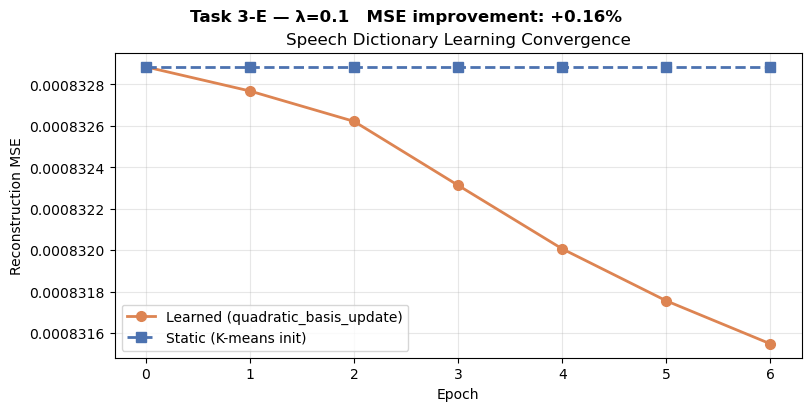

Saved t3_speech_dict_learning.png

── Synthesis: static basis ──


  0%|          | 0/100 [00:00<?, ?it/s]

── Synthesis: learned basis ──


  0%|          | 0/100 [00:00<?, ?it/s]

Saved t3_synth_static_basis.wav and t3_synth_learned_basis.wav


In [56]:
import torch
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import Audio, display, HTML

# ── Config ────────────────────────────────────────────────────────────────────
DL_SP_LAMBDA    = 0.10
DL_SP_BATCH     = 256
DL_SP_EPOCHS    = 6
DL_SP_FISTA_IT  = 60
DL_SP_STEP      = 0.002
DL_SP_LOWEST    = 1e-6
DL_SP_SYNTH_T   = 100    # frames to synthesize for comparison

# ── Init both bases from smt_basis_speech ────────────────────────────────────
sp_basis_static  = smt_basis_speech.clone().to(device)
sp_basis_learned = smt_basis_speech.clone().to(device)

sp_norm_t = torch.tensor(speech_norm, dtype=torch.float32, device=device)
N_sp      = len(sp_norm_t)

# Initial MSE
def _sp_mse(basis):
    _, m = fista_batch(speech_norm, basis, lambd=DL_SP_LAMBDA, num_iter=60, batch=512)
    return m

print("Initial MSE …")
mse_sp_static_init  = _sp_mse(sp_basis_static)
mse_sp_learned_init = _sp_mse(sp_basis_learned)
print(f"  Static  init = {mse_sp_static_init:.5f}")
print(f"  Learned init = {mse_sp_learned_init:.5f}")

hist_sp_static  = [mse_sp_static_init]
hist_sp_learned = [mse_sp_learned_init]

print(f"\nDictionary learning: {DL_SP_EPOCHS} epochs  λ={DL_SP_LAMBDA}  batch={DL_SP_BATCH}")
for epoch in range(DL_SP_EPOCHS):
    perm   = torch.randperm(N_sp, device=device)
    ep_acc = 0.0;  n_st = 0
    for i in tqdm(range(0, N_sp, DL_SP_BATCH),
                  desc=f"Epoch {epoch+1}/{DL_SP_EPOCHS}", leave=False):
        idx_e  = perm[i : i + DL_SP_BATCH]
        I_e    = sp_norm_t[idx_e].T                          # (feat, b)
        c_e    = compute_smt_embeddings(I_e, sp_basis_learned,
                                        lambd=DL_SP_LAMBDA, num_iter=DL_SP_FISTA_IT)
        Res_e  = I_e - sp_basis_learned @ c_e
        sp_basis_learned = quadratic_basis_update(
            sp_basis_learned, Res_e, c_e,
            lowest_activation=DL_SP_LOWEST,
            step_size=DL_SP_STEP, constraint="L2", nonneg=False,
        )
        ep_acc += Res_e.pow(2).mean().item() * I_e.shape[1]
        n_st   += I_e.shape[1]

    mse_l = _sp_mse(sp_basis_learned)
    mse_s = _sp_mse(sp_basis_static)
    hist_sp_learned.append(mse_l)
    hist_sp_static.append(mse_s)
    print(f"  Epoch {epoch+1:2d}  train={ep_acc/n_st:.5f}  "
          f"static={mse_s:.5f}  learned={mse_l:.5f}")

sp_improve = (mse_sp_static_init - hist_sp_learned[-1]) / mse_sp_static_init * 100
print(f"\nMSE improvement: {sp_improve:+.2f}%")

# ── Convergence plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(range(DL_SP_EPOCHS + 1), hist_sp_learned, "o-", color="#dd8452", lw=2,
        ms=7, label="Learned (quadratic_basis_update)")
ax.plot(range(DL_SP_EPOCHS + 1), hist_sp_static,  "s--", color="#4c72b0", lw=2,
        ms=7, label="Static (K-means init)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Reconstruction MSE")
ax.set_title("Speech Dictionary Learning Convergence")
ax.legend(); ax.grid(alpha=0.3)
fig.suptitle(f"Task 3-E — λ={DL_SP_LAMBDA}   MSE improvement: {sp_improve:+.2f}%",
             fontsize=12, fontweight="bold")
plt.savefig(OUTPUT_DIR / "t3_speech_dict_learning.png", dpi=150)
plt.show()
print("Saved t3_speech_dict_learning.png")

# ── Synthesis comparison: static vs learned basis ────────────────────────────
print("\n── Synthesis: static basis ──")
out_static, hist_static = synthesize_audio_mfcc(
    patches=speech_patches_tensor,
    smt_basis=sp_basis_static,
    out_time_steps=DL_SP_SYNTH_T,
    R_loc=1.0, eps=SPEECH_EPS,
)
print("── Synthesis: learned basis ──")
out_learned, hist_learned = synthesize_audio_mfcc(
    patches=speech_patches_tensor,
    smt_basis=sp_basis_learned,
    out_time_steps=DL_SP_SYNTH_T,
    R_loc=1.0, eps=SPEECH_EPS,
)

# Stitch audio
corpus_cat = np.concatenate(corpus_raw_audio_list)
sp_hop_stitch = max(1, int(round(TARGET_SR * SPEECH_HOP_MS / 1000)))
W_sp          = speech_patches_tensor.shape[3]

audio_static  = reconstruct_audio("stitch", chosen_indices=hist_static,
                                  source_audio=corpus_cat,
                                  hop_length=sp_hop_stitch, window_t=W_sp)
audio_learned = reconstruct_audio("stitch", chosen_indices=hist_learned,
                                  source_audio=corpus_cat,
                                  hop_length=sp_hop_stitch, window_t=W_sp)

# Normalise
audio_static  /= np.abs(audio_static).max()  + 1e-8
audio_learned /= np.abs(audio_learned).max() + 1e-8

# Save and play
sf.write(str(OUTPUT_DIR / "t3_synth_static_basis.wav"),  audio_static,  TARGET_SR)
sf.write(str(OUTPUT_DIR / "t3_synth_learned_basis.wav"), audio_learned, TARGET_SR)

display(HTML("<b>Non-parametric synthesis — Static K-means basis:</b>"))
display(Audio(audio_static, rate=TARGET_SR))
display(HTML(f"<b>Non-parametric synthesis — Learned basis (+{sp_improve:.1f}% MSE):</b>"))
display(Audio(audio_learned, rate=TARGET_SR))
print("Saved t3_synth_static_basis.wav and t3_synth_learned_basis.wav")
